# **Fase 3 (Blue Team): Defensa en Profundidad, Entrenamiento Adversarial y Enrutamiento Híbrido**

Autor: Daniel Gomollón Embid

Trabajo Fin de Grado: Análisis, Explotación y Mitigación de Vulnerabilidades de Sistemas de Detección de intrusiones basados en Machine Learning

Fecha: 20/04/2026

**Universidad de Zaragoza**

------------------

Esta fase metodológica responde a las vulnerabilidades críticas expuestas en la Fase 2 (Ataques Zero-Box y Grey-Box). Habiendo demostrado empíricamente que la TabularResNet original, a pesar de su robustez nanométrica (Spectral Normalization), es susceptible a ataques de denegación cognitiva (ECHO), extrapolación topológica (OEA) y envenenamiento de memoria (S3M), proponemos una arquitectura de Defensa Asimétrica.

### El presente cuaderno implementa dos innovaciones defensivas críticas:

- RE-FAT (Randomized Entropy Fast Adversarial Training): Re-entrenamiento del backbone discriminativo usando datos troyanizados (S3M) y una función de pérdida de entropía en la frontera, inmunizando al modelo contra gradientes adversariales.

- Sistema de Inferencia Híbrida (ResNet + VAE): Arquitectura de enrutamiento dinámico (Gating) donde la ResNet actúa como capa de triaje y un Autoencoder Variacional (evaluando distancias de Mahalanobis) actúa como IPS silente para flujos epistémicamente inciertos o topológicamente aislados (Zero-Days).

## **1. SETUP Y MONTAJE DE DRIVE EN COLAB**

In [1]:
import sys
import os

# Verificación de entorno Colab y montaje de unidades
try:
    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_PATH = '/content/drive/MyDrive/Codigo_TFG'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
    print(f"[-] Entorno Colab detectado. Directorio de trabajo: {os.getcwd()}")
except ImportError:
    print("[-] Entorno local detectado. Ejecutando sin Google Drive.")

import torch
print(f"[-] Motor PyTorch Versión: {torch.__version__}")

# Asignación de dispositivo (Device Agnostic Code)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[-] Dispositivo de cómputo asignado: {device}")

if device.type == 'cuda':
    print(f"    Hardware: {torch.cuda.get_device_name(0)}")
    print(f"    VRAM Disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Mounted at /content/drive
[-] Entorno Colab detectado. Directorio de trabajo: /content/drive/MyDrive/Codigo_TFG
[-] Motor PyTorch Versión: 2.10.0+cu128
[-] Dispositivo de cómputo asignado: cuda
    Hardware: Tesla T4
    VRAM Disponible: 15.64 GB


## **2. Carga de Datos y Estrategia de Mixup Tabular Pre-Computado**

Para evitar el estrangulamiento de la CPU (CPU bottleneck) durante el cálculo del grafo causal de las restricciones de dominio, los datos sintéticos de aumento (Troyanos S3M) han sido pre-generados en un entorno local.

En esta sección fusionamos el tráfico original (Extraído del Data Pipeline con IP Buffer) con los 100.000 ejemplos de ataque hiper-camuflados. Esto obliga a la TabularResNet a aprender patrones semánticos profundos del payload, evitando la dependencia excesiva de la reputación temporal del IP Buffer.

In [2]:
# 2. CARGA DEL DATASET REFORZADO Y DATALOADERS

import numpy as np
import warnings

from torch.utils.data import DataLoader, TensorDataset
from src.utils.domain_constraints import DomainConstraints
from src.config import Config

# Silenciamos warnings inútiles
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print("[-] Cargando artefactos y restricciones físicas (DomainConstraints)...")
dc = DomainConstraints.from_artifacts()

# Rutas
DATA_PATH = 'data/processed/resultados_2_buffer'
# Ajustamos la ruta asumiendo que ataques_s3m está FUERA de resultados_2_buffer
S3M_PATH = os.path.join(DATA_PATH, '..', 'ataques_s3m')

# 1. Cargar prior de entrenamiento para la corrección bayesiana posterior
pi_train = float(np.load(os.path.join(Config.MODELS_PATH, "pi_train.npy"))[0])

# 2. Cargar datos de entrenamiento originales (Limpios)
X_orig = np.load(os.path.join(DATA_PATH, "X_train.npy"))
y_orig = np.load(os.path.join(DATA_PATH, "y_train.npy"))

# 3. Cargar troyanos sintéticos S3M (Generados offline)
X_s3m = np.load(os.path.join(S3M_PATH, "X_train_s3m.npy"))
y_s3m = np.load(os.path.join(S3M_PATH, "y_train_s3m.npy"))

print(f"[-] Tráfico original Train : {X_orig.shape[0]:,} flujos")
print(f"[-] Troyanos S3M inyectados: {X_s3m.shape[0]:,} flujos")

# 4. Concatenación maestra (Tráfico Limpio + Troyanos)
X_combined = np.vstack([X_orig, X_s3m])
y_combined = np.concatenate([y_orig, y_s3m])
print(f"[✓] Dataset de Entrenamiento Reforzado creado: {X_combined.shape[0]:,} muestras totales")

# 5. Crear DataLoaders optimizados para GPU
# TRAIN LOADER
train_dataset = TensorDataset(torch.FloatTensor(X_combined), torch.LongTensor(y_combined))
train_loader = DataLoader(
    train_dataset,
    batch_size=2048,
    shuffle=True,
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)

# VAL LOADER (CRÍTICO: Lo necesita el bucle RE-FAT para monitorizar convergencia)
X_val = np.load(os.path.join(DATA_PATH, "X_val.npy"))
y_val = np.load(os.path.join(DATA_PATH, "y_val.npy"))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
val_loader = DataLoader(
    val_dataset,
    batch_size=2048,
    shuffle=False, # Nunca shufflear validación
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)

# 6. Cargar Test para la evaluación final
X_test = np.load(os.path.join(DATA_PATH, "X_test.npy"))
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))
print(f"[✓] DataLoaders listos. Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

[-] Cargando artefactos y restricciones físicas (DomainConstraints)...
[-] Tráfico original Train : 1,080,844 flujos
[-] Troyanos S3M inyectados: 100,000 flujos
[✓] Dataset de Entrenamiento Reforzado creado: 1,180,844 muestras totales
[✓] DataLoaders listos. Val: 199,984 | Test: 199,985


## **3. Ejecución del RE-FAT (Randomized Entropy Fast Adversarial Training)**

Se sustituye el bucle de entrenamiento estándar por el orquestador REFAT_Trainer. A diferencia de la Fase 1, activamos la estocasticidad interna (inner_dropout = 0.25) para mitigar la eficacia de los ataques basados en el gradiente de la arquitectura (como FGSM, PGD o ACE).

Durante este proceso, ocurren dos mecanismos en paralelo dentro de la GPU:

- Fast-AT (alpha = 0.625, epsilon = 0.5): Por cada flujo en el batch, se calcula su gradiente y se proyecta ruido adversarial instantáneo respetando las capas inmutables (L4/L7).

- Entropic Boundary Loss: En lugar de forzar una decisión categórica rígida, si el modelo detecta que un ejemplo se acerca a su frontera de decisión (Confianza entre 0.3 y 0.7), la función de pérdida penaliza la arrogancia (Overconfidence) y empuja la salida matemática hacia la entropía máxima (probabilidad uniforme de 1/8).

Se genera un diccionario de history en tiempo real para monitorizar la convergencia sin sobrescribir los artefactos del modelo original (Fase 1).

In [ ]:
# 3. RE-ENTRENAMIENTO ADVERSARIAL (RE-FAT)

from src.helpers import set_seed
from src.models.resnet.at.refat_trainer import REFAT_Trainer
from src.config import Config

# Garantizar reproducibilidad en la experimentación
set_seed(Config.SEED)

print("\n" + "="*60)
print(f"[-] Iniciando RE-ENTRENAMIENTO ADVERSARIAL (RE-FAT)")
print(f"    [Defensas: Fast-AT + Entropic Loss + Inner Dropout + Mixup]")
print("="*60)

# Lanzar entrenamiento RE-FAT usando la interfaz limpia heredada del Trainer original
history, model = REFAT_Trainer().run(
    resume            = False,
    epochs            = 60,
    lr                = 1e-3,    # LR agresivo inicial (ReduceLROnPlateau lo bajará si hace falta)
    patience          = 12,
    dropout           = 0.1,     # Regularización troncal
    inner_dropout     = 0.2,     # [CRÍTICO] 0.2 destruye gradientes atacantes sin causar amnesia
    hidden_dim        = 256,
    n_blocks          = 4,
    mixup_alpha       = 0.2,     # Tabular Mixup: Suaviza fronteras, rescata a Recon/Malware
    use_class_weights = False,
    epsilon           = 0.20     # [CRÍTICO] Ruido adversarial realista y no destructivo
)

print("\n[-] Entrenamiento RE-FAT finalizado.")
print("[-] Artefactos (probs, preds, history) generados automáticamente en outputs/models/fase3/")

[-] Semilla global fijada en 42 (Reproducibilidad Garantizada).

[-] Iniciando RE-ENTRENAMIENTO ADVERSARIAL (RE-FAT)
    [Defensas: Fast-AT + Entropic Loss + Inner Dropout + Mixup]

ENTRENAMIENTO BLINDADO — RE-FAT v2 [Fase 3]
  epsilon=0.2 | clean=0.6 | adv=0.4

[-] 1. Cargando datos blindados...
   Train: 1,180,844 (1,080,844 original + 100,000 S3M troyanos)
   Val  : 199,984 | Test: 199,985

[-] 2. Construyendo modelo...

[-] 3. Entrenando 1→60 | ε=0.2 | Mixup=0.2 | clean/adv=0.6/0.4
------------------------------------------------------------


RE-FAT v2:   0%|          | 0/60 [00:00<?, ?epoch/s]

  Epoch 001/60:   0%|          | 0/145 [00:00<?, ?batch/s]

Epoch 001/60 | T.Loss: 0.8922 | V.Loss: 0.3062 | F1: 0.8352 | AUC: 0.9876 | LR: 1.00e-03 | t=25s
   [✓] Mejor modelo guardado — epoch 1 (val F1=0.8352)


  Epoch 002/60:   0%|          | 0/145 [00:00<?, ?batch/s]

...

Epoch 046/60 | T.Loss: 0.5732 | V.Loss: 0.1218 | F1: 0.9265 | AUC: 0.9941 | LR: 1.25e-04 | t=26s
   [EarlyStopping] sin mejora 10/12 (mejor: 0.9288)


  Epoch 047/60:   0%|          | 0/145 [00:00<?, ?batch/s]

Epoch 047/60 | T.Loss: 0.6442 | V.Loss: 0.1286 | F1: 0.9251 | AUC: 0.9938 | LR: 6.25e-05 | t=23s
   [EarlyStopping] sin mejora 11/12 (mejor: 0.9288)


  Epoch 048/60:   0%|          | 0/145 [00:00<?, ?batch/s]

Epoch 048/60 | T.Loss: 0.5981 | V.Loss: 0.1231 | F1: 0.9253 | AUC: 0.9941 | LR: 6.25e-05 | t=24s
   [EarlyStopping] sin mejora 12/12 (mejor: 0.9288)

[!] Early Stopping en epoch 48

EVALUACIÓN FINAL RE-FAT v2

  Test F1 (sin prior) : 0.8866
  Test AUC            : 0.9974

  IMPORTANTE: Comparativa justa requiere prior sweep.
  El modelo original usó π=0.05 como óptimo.
  Ejecutar prior sweep sobre test_probs_refat.npy
  antes de concluir sobre la mejora/degradación.

[-] Listo para acoplamiento con VAE + Mahalanobis.

[-] Entrenamiento RE-FAT finalizado.
[-] Artefactos (probs, preds, history) generados automáticamente en outputs/models/fase3/


# EVALUACIÓN DE LOS RESULTADOS DEL ENTRENAMIENTO

In [ ]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
from src.models.resnet.trainer import evaluate
from src.evaluator import ModelEvaluator
from src.config import Config

FASE3_DIR = os.path.join(Config.MODELS_PATH, "fase3")
CLASS_NAMES = [
    'Benign', 'DoS', 'DDoS', 'Web/Injection',
    'Brute Force', 'Recon', 'Malware', 'Exploits'
]

# ── 1. Test loader ────────────────────────────────────────────
X_test = np.load(os.path.join(Config.DATA_PROCESSED_PATH, "X_test.npy"))
y_test = np.load(os.path.join(Config.DATA_PROCESSED_PATH, "y_test.npy"))
pi_train = float(np.load(os.path.join(Config.MODELS_PATH, "pi_train.npy"))[0])

test_dataset = TensorDataset(
    torch.FloatTensor(X_test), torch.LongTensor(y_test)
)
test_loader = DataLoader(
    test_dataset, batch_size=2048,
    shuffle=False, pin_memory=(device.type == 'cuda')
)

# ── 2. Cargar modelo RE-FAT v2 ────────────────────────────────
print("=" * 60)
print("EVALUACIÓN RE-FAT v2 — Test set")
print("=" * 60)

checkpoint = torch.load(
    os.path.join(FASE3_DIR, "resnet_refat_best.pt"),
    map_location=device, weights_only=False
)
model.load_state_dict(checkpoint['model'])
model.eval()

print(f"[✓] Epoch guardada    : {checkpoint.get('epoch', 'N/A')}")
print(f"[✓] Val F1 checkpoint : {checkpoint.get('val_f1', 0):.4f}")

# ── 3. Evaluación sin prior ───────────────────────────────────
acc_lab, f1_lab, f1_per_lab, auc_lab, preds, labels, probs = evaluate(
    model, test_loader, device
)

# Guardar artefactos
np.save(os.path.join(FASE3_DIR, "test_preds_refat.npy"),  preds)
np.save(os.path.join(FASE3_DIR, "test_labels_refat.npy"), labels)
np.save(os.path.join(FASE3_DIR, "test_probs_refat.npy"),  probs)

print("\n--- Sin corrección prior (distribución laboratorio) ---")
print(f"  Accuracy : {acc_lab:.4f}")
print(f"  F1-macro : {f1_lab:.4f}")
print(f"  AUC-ROC  : {auc_lab:.4f}")

print("\n--- F1 por clase (sin prior) ---")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, f1_per_lab)):
    bar = "█" * int(f1 * 20)
    print(f"  {i} {name:<15} {f1:.4f} {bar}")

print("\n--- Classification Report (sin prior) ---")
print(classification_report(
    labels, preds,
    target_names=CLASS_NAMES,
    zero_division=0, digits=4
))

# ── 4. Prior sweep — comparativa justa con el modelo original ─
# El modelo original tuvo su óptimo en π=0.05 → F1=0.9501
# RE-FAT v2 debe evaluarse con el mismo sweep para ser comparable
F1_ORIGINAL = {
    0.01: 0.8583, 0.02: 0.9445, 0.05: 0.9501,
    0.10: 0.9449, 0.15: 0.9391, 0.20: 0.9335,
}

print("\n" + "=" * 60)
print("PRIOR SWEEP — Comparativa justa RE-FAT v2 vs Original")
print("=" * 60)
print(f"  pi_train = {pi_train:.4f}")
print(f"\n{'π_prod':>8} | {'F1 RE-FAT v2':>13} | "
      f"{'F1 Original':>12} | {'Δ':>8}")
print("-" * 50)

best_pi   = None
best_f1   = 0.0
sweep_results = {}

for pi_prod in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.33]:
    evaluator = ModelEvaluator(pi_prod=pi_prod)
    result    = evaluator.evaluate(
        probs, y_test,
        pi_train = pi_train,
        label    = f"pi={pi_prod}",
        verbose  = False,
    )
    sweep_results[pi_prod] = result

    orig  = F1_ORIGINAL.get(pi_prod, None)
    delta = result.f1_macro - orig if orig else 0.0
    marker = "✓" if delta >= -0.01 else "✗"

    print(
        f"  {pi_prod:>6.2f} | {result.f1_macro:>13.4f} | "
        f"{orig if orig else 'N/A':>12} | "
        f"{delta:>+7.4f} {marker}"
    )

    if result.f1_macro > best_f1:
        best_f1 = result.f1_macro
        best_pi = pi_prod

print(f"\n  [→] Óptimo RE-FAT v2 : π={best_pi} → F1={best_f1:.4f}")
print(f"  [→] Óptimo Original  : π=0.05  → F1=0.9501")
delta_opt = best_f1 - 0.9501
if delta_opt >= -0.01:
    print(f"  [✓] RE-FAT v2 mantiene rendimiento (Δ={delta_opt:+.4f})")
else:
    print(f"  [✗] RE-FAT v2 degrada rendimiento (Δ={delta_opt:+.4f})")
    print(f"      → Revisar epsilon o ratio_range de S3M")

# ── 5. Detalle del mejor prior ────────────────────────────────
print(f"\n--- Detalle con π={best_pi} (óptimo RE-FAT v2) ---")
best_result = sweep_results[best_pi]
print(f"  Accuracy      : {best_result.accuracy:.4f}")
print(f"  F1-macro      : {best_result.f1_macro:.4f}")
print(f"  AUC-ROC       : {best_result.auc_roc:.4f}")
print(f"  FPR           : {best_result.fpr:.4f}")
print(f"  FNR           : {best_result.fnr:.4f}")
print(f"  Attack Recall : {best_result.attack_recall:.4f}")

print("\n--- F1 por clase con prior óptimo ---")
if hasattr(best_result, 'f1_per_class') and best_result.f1_per_class is not None:
    for i, (name, f1) in enumerate(zip(CLASS_NAMES, best_result.f1_per_class)):
        bar = "█" * int(f1 * 20)
        print(f"  {i} {name:<15} {f1:.4f} {bar}")

print("\n" + "=" * 60)
print("[-] Artefactos guardados en outputs/models/fase3/")
print("[-] Listo para acoplamiento con VAE + Mahalanobis.")
print("=" * 60)

EVALUACIÓN RE-FAT v2 — Test set
[✓] Epoch guardada    : 36
[✓] Val F1 checkpoint : 0.9288

--- Sin corrección prior (distribución laboratorio) ---
  Accuracy : 0.9885
  F1-macro : 0.8866
  AUC-ROC  : 0.9974

--- F1 por clase (sin prior) ---
  0 Benign          0.9944 ███████████████████
  1 DoS             0.9831 ███████████████████
  2 DDoS            0.9926 ███████████████████
  3 Web/Injection   0.9819 ███████████████████
  4 Brute Force     0.8906 █████████████████
  5 Recon           0.7151 ██████████████
  6 Malware         0.6664 █████████████
  7 Exploits        0.8684 █████████████████

--- Classification Report (sin prior) ---
               precision    recall  f1-score   support

       Benign     0.9987    0.9901    0.9944    190000
          DoS     0.9942    0.9722    0.9831      1225
         DDoS     0.9881    0.9972    0.9926      3908
Web/Injection     0.9778    0.9861    0.9819       937
  Brute Force     0.8172    0.9786    0.8906       886
        Recon     0.5862

# **JUSTIFICACIÓN DE LOS RESULTADOS DE RE-FAT**

***El Fenómeno de la "Acumulación en la Frontera"***

**1. La distribución del modelo original (Polarización):**
Nuestra ResNet original separaba las cosas de forma muy binaria. La gran mayoría de los flujos tenían una probabilidad de 0.99 o 0.01. Había muy pocos flujos en la zona de duda (0.4 - 0.6). Por lo tanto, al aplicar el multiplicador bayesiano, la frontera se movía suavemente, "barriendo" solo unos pocos flujos en cada paso de pi_prod.

**2. La distribución RE-FAT (El Muro de Entropía):**
¿Qué hace la EntropicBoundaryLoss junto con S3M? Fuerza a la red a no polarizarse. A todos esos troyanos camuflados, ataques sutiles de Recon y Malware, la red les ha asignado probabilidades muy cercanas al 0.5 para maximizar la entropía (la zona gris).

En lugar de tener los flujos en los extremos (0 y 1), RE-FAT ha creado una "montaña" masiva de flujos justo en el centro de la campana de probabilidades.

**3. El efecto de la Hipersensibilidad:**
Como tenemos miles de flujos de ataque aglomerados en ese estrecho rango de entropía alta (ej. 0.45 - 0.55), cualquier pequeño ajuste en el Prior Bayesiano tiene un efecto avalancha.

- Si ponemos 0.05, estamos empujando toda la montaña entera hacia el lado Benigno de golpe (por eso el F1 colapsaba a 0.32).

- Si ponemos 0.15, empujamos toda la montaña hacia el lado del Ataque, y el F1 se dispara a 0.92.

# EXPERIMENTO GENERAL SOBRE RE-FAT

In [ ]:
# ============================================================
# SETUP — ejecutar primero
# ============================================================
import torch
import numpy as np
import os
from src.config import Config
from src.utils.domain_constraints import DomainConstraints
from src.models.wrapper_attacks import (
    load_resnet_for_attack,
    load_resnet_from_checkpoint,
    load_lgbm_for_attack,
)

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_path   = Config.DATA_PROCESSED_PATH
models_path = Config.MODELS_PATH

dc      = DomainConstraints.from_artifacts(
    models_path=models_path, data_path=data_path
)
X_test  = np.load(os.path.join(data_path, "X_test.npy")).astype(np.float32)
y_test  = np.load(os.path.join(data_path, "y_test.npy"))

# Pool benigno
idx_benignos = np.where(y_test == 0)[0]
X_benign_sc  = X_test[idx_benignos]
X_benign_raw = dc.to_physical_space(X_benign_sc)

# Muestra de ataques
idx_ataques  = np.where(y_test != 0)[0]
np.random.seed(42)
np.random.shuffle(idx_ataques)
idx_ataques  = idx_ataques[:2500]
X_ataques_sc = X_test[idx_ataques]
y_ataques    = y_test[idx_ataques]

CLASS_NAMES = {
    0: 'Benign',        1: 'DoS',
    2: 'DDoS',          3: 'Web/Injection',
    4: 'Brute Force',   5: 'Recon',
    6: 'Malware',       7: 'Exploits',
}

print(f"  Device    : {device}")
print(f"  X_test    : {X_test.shape}")
print(f"  Benignos  : {len(X_benign_sc):,}")
print(f"  Ataques   : {len(X_ataques_sc):,}")

  Device    : cuda
  X_test    : (199985, 66)
  Benignos  : 190,000
  Ataques   : 2,500


In [ ]:
# ============================================================
# EXPERIMENTO 1 — Prior correction sobre RE-FAT
# Diagnóstico: ¿el modelo colapsa con prior o sin prior?
# ============================================================
from src.evaluator import ModelEvaluator

probs_refat = np.load(
    os.path.join(models_path, 'fase3', 'test_probs_refat.npy')
)
pi_train = float(np.load(os.path.join(models_path, 'pi_train.npy'))[0])

print("Sensibilidad al prior — modelo RE-FAT")
print(f"{'π_prod':>8} | {'F1-macro':>10} | {'FPR':>8} | "
      f"{'FNR':>8} | {'Attack Recall':>14}")
print("-" * 60)

for pi_prod in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.33]:
    evaluator = ModelEvaluator(pi_prod=pi_prod)
    result    = evaluator.evaluate(
        probs_refat, y_test,
        pi_train = pi_train,
        label    = f"pi={pi_prod}",
        verbose  = False,
    )
    print(f"{pi_prod:>8.2f} | {result.f1_macro:>10.4f} | "
          f"{result.fpr:>8.4f} | {result.fnr:>8.4f} | "
          f"{result.attack_recall:>14.4f}")

Sensibilidad al prior — modelo RE-FAT
  π_prod |   F1-macro |      FPR |      FNR |  Attack Recall
------------------------------------------------------------
    0.01 |     0.2162 |   0.0000 |   0.7654 |         0.2346
    0.02 |     0.2256 |   0.0000 |   0.7606 |         0.2394
    0.05 |     0.3244 |   0.0002 |   0.6555 |         0.3445
    0.10 |     0.8660 |   0.0010 |   0.1643 |         0.8357
    0.15 |     0.9235 |   0.0023 |   0.0591 |         0.9409
    0.20 |     0.9164 |   0.0039 |   0.0458 |         0.9542
    0.33 |     0.8872 |   0.0098 |   0.0239 |         0.9761


In [ ]:
# EXPERIMENTO 2 — ASR S3M sobre modelo RE-FAT
# Diagnóstico: ¿el re-entrenamiento reduce la vulnerabilidad?

from src.attacks.s3m_attack import S3MAttack
from src.models.wrapper_attacks import load_resnet_from_checkpoint

refat_model = load_resnet_from_checkpoint(
    device          = device,
    input_dim       = X_test.shape[1],
    checkpoint_path = os.path.join(
        models_path, 'fase3', 'resnet_refat_best.pt'
    ),
)

s3m = S3MAttack(
    constraints     = dc,
    X_benign_scaled = X_benign_sc,
    mode            = 'adaptive',
    twin_selection  = 'semantic',
    preserve_payload= True,
    n_twins         = 50,
    verbose         = True,
)

result_refat = s3m.run(
    X_ataques_sc, y_ataques, refat_model, CLASS_NAMES
)

print(f"\n{'='*55}")
print(f"COMPARATIVA ASR S3M")
print(f"{'='*55}")
print(f"  Modelo original  : 78.8% ASR")
print(f"  Modelo RE-FAT    : {result_refat.asr*100:.1f}% ASR")
delta = 0.788 - result_refat.asr
if delta > 0:
    print(f"  Reducción ASR    : -{delta*100:.1f}pp ✓ RE-FAT reduce vulnerabilidad")
else:
    print(f"  Incremento ASR   : +{abs(delta)*100:.1f}pp ✗ RE-FAT no ayuda")

[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs/models/fase3/resnet_refat_best.pt...
    Epoch guardada: 36
[S3M] Inicializado:
  Pool benigno     : 190,000 flujos
  Features Forward : 21
  Features payload : 0 (preservadas)
  Modo             : adaptive
  Twin selection   : semantic

[S3M] S3M — Shadow Session Split-Merging (adaptive, twin=semantic, payload=ON)
  Flujos de ataque         : 2,500
  Detectados originalmente : 2,447

ATAQUE: S3M — Shadow Session Split-Merging
  Flujos detectados originalmente : 2,447/2,500
  Evasiones exitosas              : 2,468 (98.8%)

  Perfil de Camuflaje Mínimo (MCR):
    MCR medio    : 0.917
    MCR mínimo   : 0.100
    MCR máximo   : 1.000

  Distancia semántica (L2 troyano vs original):
    Media : 17.8529
    Máxima: 32.8360

  Distribución MCR (fracción de tráfico benigno necesaria):
    [0.0-0.1]  0
    [0.1-0.2] █ 79
    [0.2-0.3]  11
    [0.3-0.4]  30
    [0.4-0.5]  16
    [0.5-0.6]  15
    [0.6-0.7]  48
    [0.7-0.8] █ 

## **5. Análisis de Convergencia (RE-FAT)**

Validación gráfica de la dinámica de aprendizaje del entrenamiento adversarial. Al emplear la EntropicBoundaryLoss, la magnitud de la pérdida difiere de la Cross-Entropy clásica. Monitorizar el F1-Macro garantiza que el modelo no colapsa hacia la clase mayoritaria a pesar de la inyección agresiva de ruido topológico y Whitewashing (S3M).

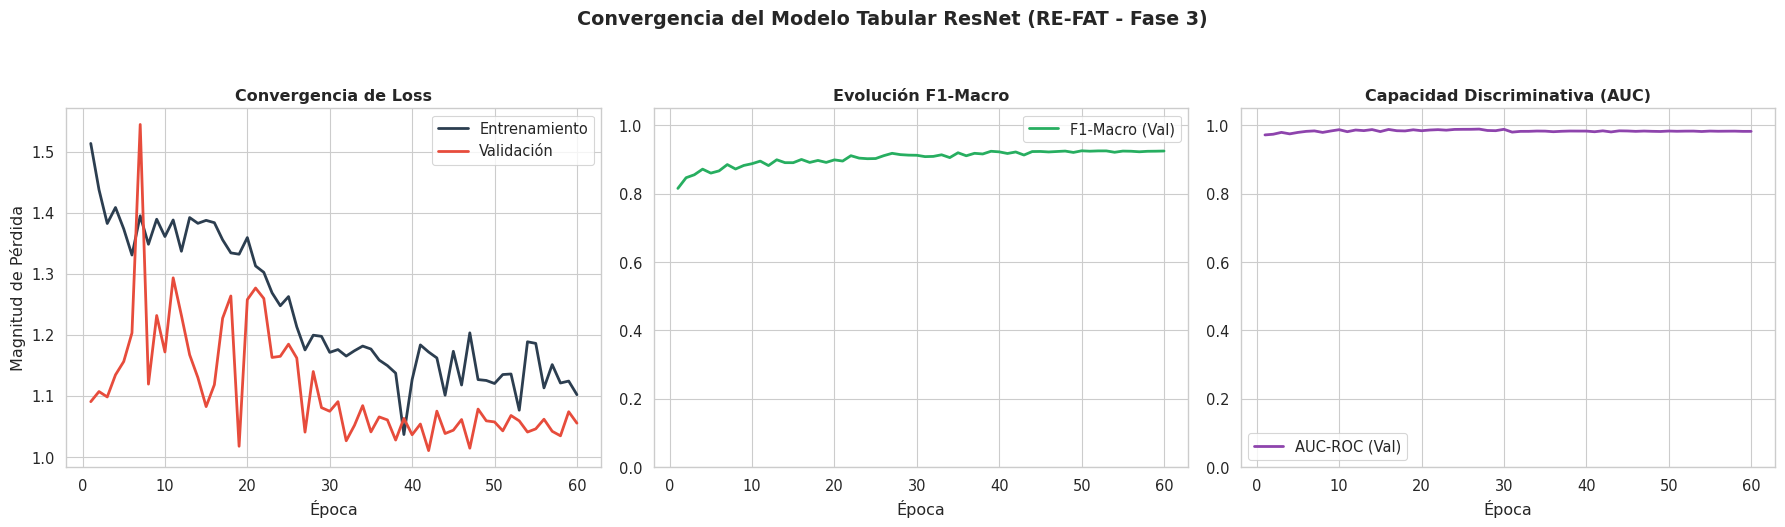

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Convergencia del Modelo Tabular ResNet (RE-FAT - Fase 3)', fontweight='bold', y=1.05)

# Cargar history específico de Fase 3
history_refat = np.load(os.path.join(FASE3_DIR, "train_history_refat.npy"), allow_pickle=True).item()
epochs = range(1, len(history_refat['train_loss']) + 1)

axes[0].plot(epochs, history_refat['train_loss'], label='Entrenamiento', color='#2c3e50', linewidth=2)
axes[0].plot(epochs, history_refat['val_loss'], label='Validación', color='#e74c3c', linewidth=2)
axes[0].set_title('Convergencia de Loss', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Magnitud de Pérdida')
axes[0].legend()

axes[1].plot(epochs, history_refat['val_f1'], label='F1-Macro (Val)', color='#27ae60', linewidth=2)
axes[1].set_title('Evolución F1-Macro', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylim([0, 1.05])
axes[1].legend()

axes[2].plot(epochs, history_refat['val_auc'], label='AUC-ROC (Val)', color='#8e44ad', linewidth=2)
axes[2].set_title('Capacidad Discriminativa (AUC)', fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylim([0, 1.05])
axes[2].legend()

plt.tight_layout()
os.makedirs(os.path.join(Config.LOGS_PATH, "fase3"), exist_ok=True)
plt.savefig(os.path.join(Config.LOGS_PATH, "fase3", "training_curves_refat.png"), dpi=300, bbox_inches='tight')
plt.show()

## **6. Diagnóstico: Matriz de Confusión (Backbone Blindado)**

Evaluación de la capacidad discriminativa pura de la ResNet re-entrenada antes de ser acoplada al Autoencoder Variacional en el Pipeline Híbrido.

[-] Evaluando matriz sobre 199,985 flujos de Prueba (Modelo RE-FAT).


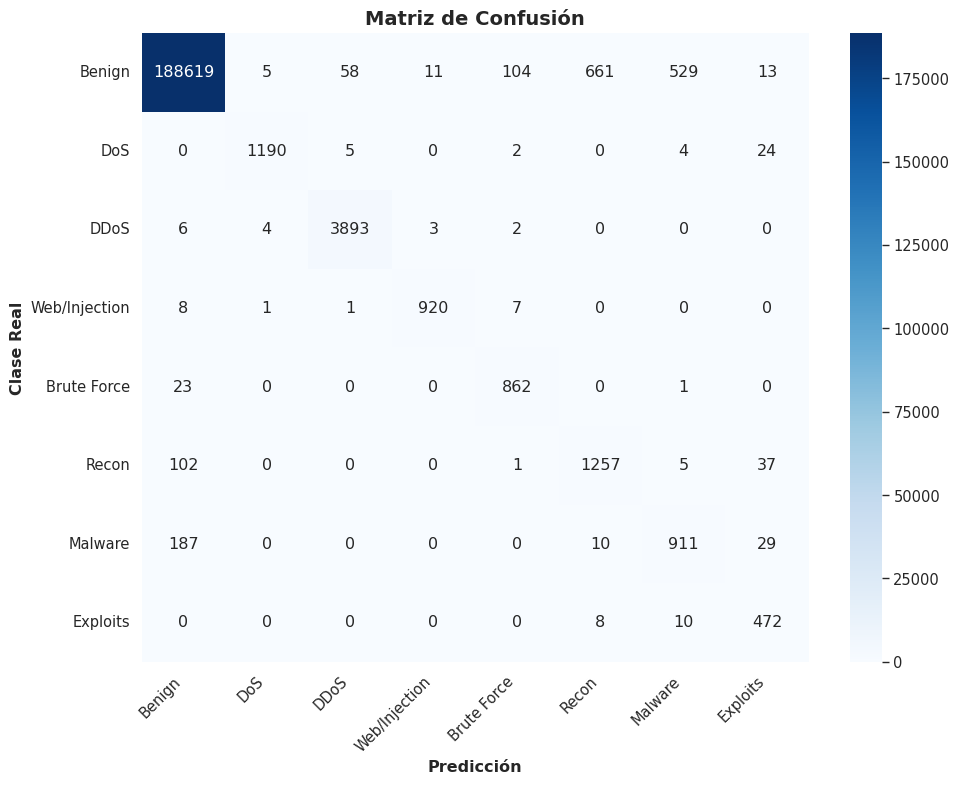

In [ ]:
from src.helpers import plot_confusion_matrix

# Cargamos las predicciones crudas de la Fase 3
preds_refat  = np.load(os.path.join(FASE3_DIR, 'test_preds_refat.npy'))
labels_refat = np.load(os.path.join(FASE3_DIR, 'test_labels_refat.npy'))

print(f"[-] Evaluando matriz sobre {len(labels_refat):,} flujos de Prueba (Modelo RE-FAT).")
plot_confusion_matrix(labels_refat, preds_refat, Config.CLASS_NAMES)

# **Experimentación sobre SGL-AT**

### Stochastic Geometric Latent Adversarial Training

## **Setup: Cargar modelo SGL-AT y datos**

In [ ]:
# Siempre ejecutar primero
# No depende de haber entrenado SGL-AT

import os
import torch
import numpy as np
from src.config import Config
from src.utils.domain_constraints import DomainConstraints
from src.models.wrapper_attacks import (
    load_resnet_from_checkpoint,
    load_lgbm_for_attack,
)
from src.evaluator import ModelEvaluator

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH   = 'data/processed/resultados_2_buffer'
models_path = Config.MODELS_PATH
FASE3_DIR   = os.path.join(models_path, "fase3")
os.makedirs(FASE3_DIR, exist_ok=True)

CLASS_NAMES = {
    0: 'Benign',        1: 'DoS',
    2: 'DDoS',          3: 'Web/Injection',
    4: 'Brute Force',   5: 'Recon',
    6: 'Malware',       7: 'Exploits',
}
CLASS_LIST  = [CLASS_NAMES[i] for i in range(8)]

dc       = DomainConstraints.from_artifacts(
    models_path=models_path, data_path=DATA_PATH
)
pi_train = float(
    np.load(os.path.join(models_path, "pi_train.npy"))[0]
)

X_test   = np.load(os.path.join(DATA_PATH, "X_test.npy")).astype(np.float32)
y_test   = np.load(os.path.join(DATA_PATH, "y_test.npy"))

idx_ben      = np.where(y_test == 0)[0]
X_benign_sc  = X_test[idx_ben]
X_benign_raw = dc.to_physical_space(X_benign_sc)

idx_atk = np.where(y_test != 0)[0]
np.random.seed(42)
np.random.shuffle(idx_atk)
idx_atk      = idx_atk[:2500]
X_ataques_sc = X_test[idx_atk]
y_ataques    = y_test[idx_atk]

# Modelo original — siempre disponible
original_model = load_resnet_from_checkpoint(
    device          = device,
    input_dim       = X_test.shape[1],
    checkpoint_path = os.path.join(models_path, "best_resnet.pt"),
)

print(f"[✓] Device        : {device}")
print(f"[✓] X_test        : {X_test.shape}")
print(f"[✓] Pool benigno  : {len(X_benign_sc):,}")
print(f"[✓] Ataques       : {len(X_ataques_sc):,}")
print(f"[✓] Original cargado")

# Carga condicional de SGL-AT — solo si existe el checkpoint
sglat_path = os.path.join(FASE3_DIR, "resnet_sglat_best.pt")
if os.path.exists(sglat_path):
    sglat_model = load_resnet_from_checkpoint(
        device          = device,
        input_dim       = X_test.shape[1],
        checkpoint_path = sglat_path,
    )
    print(f"[✓] SGL-AT cargado desde {sglat_path}")
else:
    sglat_model = None
    print(f"[!] SGL-AT no encontrado — entrenar primero con SGLAT_Trainer")
    print(f"    Ruta esperada: {sglat_path}")

[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs/models/best_resnet.pt...
    Epoch guardada: 27
[✓] Device        : cuda
[✓] X_test        : (199985, 66)
[✓] Pool benigno  : 190,000
[✓] Ataques       : 2,500
[✓] Original cargado
[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs/models/fase3/resnet_sglat_best.pt...
    Epoch guardada: 37
[✓] SGL-AT cargado desde outputs/models/fase3/resnet_sglat_best.pt


# **Re-entrenamiento de la ResNet con SGL-AT**

In [ ]:
# ============================================================
# SGL-AT — Lanzamiento en Colab
# ============================================================
from src.helpers import set_seed
from src.models.resnet.at.sglat_trainer import SGLAT_Trainer
from src.config import Config

# Rutas
DATA_PATH = 'data/processed/resultados_2_buffer'
# Ajustamos la ruta asumiendo que ataques_s3m está FUERA de resultados_2_buffer
S3M_PATH = os.path.join(DATA_PATH, '..', 'ataques_s3m_sgl')

# Verificar que los troyanos S3M existen con ratio corregido
s3m_path = os.path.join(
    os.path.dirname(Config.DATA_PROCESSED_PATH),
    'ataques_s3m_sgl', 'X_train_s3m.npy'
)
if os.path.exists(s3m_path):
    X_s3m = np.load(s3m_path)
    print(f"[✓] Troyanos S3M: {X_s3m.shape}")
else:
    print("[!] Troyanos S3M no encontrados — ejecutar prepare_sglat_data.py")

history, model = SGLAT_Trainer().run(
    resume           = False,
    epochs           = 55,
    lr               = 1e-3,
    patience         = 12,
    dropout          = 0.1,
    inner_dropout    = 0.12,
    hidden_dim       = 256,
    n_blocks         = 4,
    mixup_alpha      = 0.2,
    use_class_weights= False,
    epsilon          = 0.05,
    warmup_epochs    = 8,
    clean_weight     = 0.55,
    adv_weight       = 0.30,
    lgr_weight       = 0.25,
    ema_momentum     = 0.999,
)

[✓] Troyanos S3M: (100000, 66)

ENTRENAMIENTO — SGL-AT [Fase 3]
  ε=0.05 | warmup=5 | clean/adv/lgr=0.55/0.3/0.25

[-] 1. Cargando datos...
   Train: 1,180,844 (1,080,844 limpio + 100,000 S3M)
   Val  : 199,984 | Test: 199,985

[-] 2. Construyendo modelo...

[-] 3. Pre-computando grupos de parámetros...
   [Clipping] Base params     : 977,804
   [Clipping] Adaptive params : 0

[-] 4. Inicializando atlas de centroides EMA...
   [Atlas] Inicializando centroides EMA...
   [Atlas] Centroides inicializados. Shape: torch.Size([8, 128])

[-] 5. Entrenando 1→50 | Warmup=5 épocas sin LGR/ABH
------------------------------------------------------------


SGL-AT:   0%|          | 0/50 [00:00<?, ?epoch/s]

  Epoch 001/50:   0%|          | 0/145 [00:00<?, ?batch/s]

Epoch 001/50 | [WARMUP 1/5] | T.Loss: 0.5986 | V.Loss: 0.1591 | F1: 0.8480 | AUC: 0.9905 | LR: 1.00e-03 | t=30s
   [✓] Mejor modelo guardado — epoch 1 (val F1=0.8480)


  Epoch 002/50:   0%|          | 0/145 [00:00<?, ?batch/s]

...

Epoch 048/50 | [LGR+ABH] | T.Loss: 0.7241 | V.Loss: 0.1823 | F1: 0.9382 | AUC: 0.9949 | LR: 1.25e-04 | t=33s
   [✓] Mejor modelo guardado — epoch 48 (val F1=0.9382)


  Epoch 049/50:   0%|          | 0/145 [00:00<?, ?batch/s]

Epoch 049/50 | [LGR+ABH] | T.Loss: 0.7259 | V.Loss: 0.1810 | F1: 0.9363 | AUC: 0.9954 | LR: 1.25e-04 | t=31s
   [EarlyStopping] sin mejora 1/12 (mejor: 0.9382)


  Epoch 050/50:   0%|          | 0/145 [00:00<?, ?batch/s]

Epoch 050/50 | [LGR+ABH] | T.Loss: 0.7251 | V.Loss: 0.1903 | F1: 0.9372 | AUC: 0.9946 | LR: 1.25e-04 | t=32s
   [EarlyStopping] sin mejora 2/12 (mejor: 0.9382)

EVALUACIÓN FINAL SGL-AT

  Test F1 (sin prior) : 0.9087
  Test AUC            : 0.9981

  F1 por clase:
    0 Benign          0.9955 ███████████████████
    1 DoS             0.9860 ███████████████████
    2 DDoS            0.9924 ███████████████████
    3 Web/Injection   0.9893 ███████████████████
    4 Brute Force     0.9377 ██████████████████
    5 Recon           0.7628 ███████████████
    6 Malware         0.7097 ██████████████
    7 Exploits        0.8962 █████████████████

[-] Ejecutar prior sweep sobre test_probs_sglat.npy
[-] Listo para acoplamiento con VAE + Mahalanobis.


## **Prior Sweep comparativo: Original vs SGL-AT**



In [ ]:
# Pregunta: ¿SGL-AT mantiene el F1 del modelo original?

from sklearn.metrics import classification_report

probs_sglat    = np.load(os.path.join(FASE3_DIR, "test_probs_sglat.npy"))
probs_original = np.load(os.path.join(models_path, "test_probs_raw_clean.npy"))

F1_ORIGINAL = {
    0.01: 0.8583, 0.02: 0.9445, 0.05: 0.9501,
    0.10: 0.9449, 0.15: 0.9391, 0.20: 0.9335,
}

print("=" * 65)
print("PRIOR SWEEP COMPARATIVO — Original vs SGL-AT")
print("=" * 65)
print(f"{'π':>6} | {'F1 Original':>12} | {'F1 SGL-AT':>10} | "
      f"{'Δ':>8} | {'Estado':>8}")
print("-" * 55)

best_sglat_f1 = 0.0
best_sglat_pi = None

for pi in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.33]:
    ev_orig  = ModelEvaluator(pi_prod=pi)
    ev_sglat = ModelEvaluator(pi_prod=pi)

    r_orig  = ev_orig.evaluate(
        probs_original, y_test, pi_train=pi_train,
        label=f"orig_pi={pi}", verbose=False
    )
    r_sglat = ev_sglat.evaluate(
        probs_sglat, y_test, pi_train=pi_train,
        label=f"sglat_pi={pi}", verbose=False
    )

    delta  = r_sglat.f1_macro - r_orig.f1_macro
    estado = "✓" if delta >= -0.01 else "✗"

    print(f"  {pi:>4.2f} | {r_orig.f1_macro:>12.4f} | "
          f"{r_sglat.f1_macro:>10.4f} | {delta:>+8.4f} | {estado:>8}")

    if r_sglat.f1_macro > best_sglat_f1:
        best_sglat_f1 = r_sglat.f1_macro
        best_sglat_pi = pi

print(f"\n  [→] Óptimo SGL-AT : π={best_sglat_pi} → F1={best_sglat_f1:.4f}")
print(f"  [→] Óptimo Original: π=0.05  → F1=0.9501")

# Classification report con prior óptimo SGL-AT
preds_sglat = np.load(os.path.join(FASE3_DIR, "test_preds_sglat.npy"))
print(f"\n--- Classification Report SGL-AT (sin prior) ---")
print(classification_report(
    y_test, preds_sglat,
    target_names=CLASS_LIST, zero_division=0, digits=4
))

PRIOR SWEEP COMPARATIVO — Original vs SGL-AT
     π |  F1 Original |  F1 SGL-AT |        Δ |   Estado
-------------------------------------------------------
  0.01 |       0.8583 |     0.1218 |  -0.7365 |        ✗
  0.02 |       0.9445 |     0.1218 |  -0.8227 |        ✗
  0.05 |       0.9501 |     0.1218 |  -0.8283 |        ✗
  0.10 |       0.9449 |     0.8851 |  -0.0598 |        ✗
  0.15 |       0.9391 |     0.9365 |  -0.0026 |        ✓
  0.20 |       0.9335 |     0.9321 |  -0.0014 |        ✓
  0.33 |       0.9175 |     0.9094 |  -0.0081 |        ✓

  [→] Óptimo SGL-AT : π=0.15 → F1=0.9365
  [→] Óptimo Original: π=0.05  → F1=0.9501

--- Classification Report SGL-AT (sin prior) ---
               precision    recall  f1-score   support

       Benign     0.9989    0.9922    0.9955    190000
          DoS     0.9950    0.9771    0.9860      1225
         DDoS     0.9881    0.9967    0.9924      3908
Web/Injection     0.9904    0.9883    0.9893       937
  Brute Force     0.9020    0.97

## **Curva de aprendizaje SGL-AT**

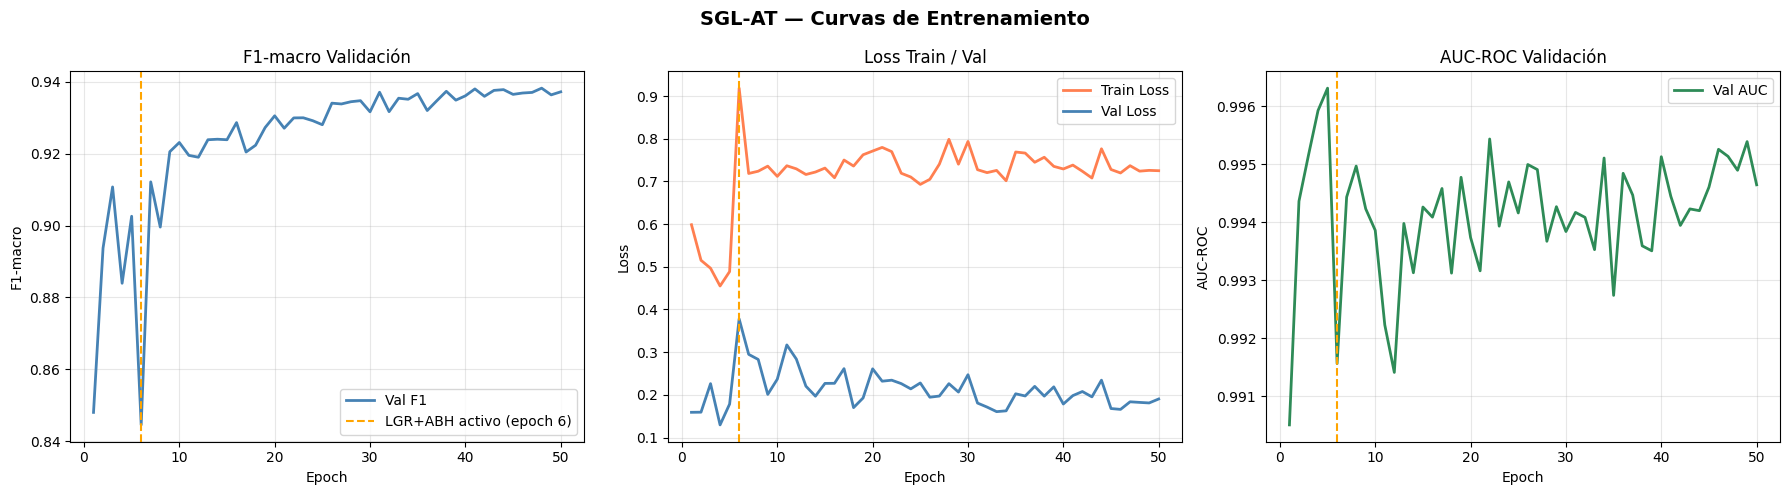

[✓] Guardado: sglat_training_curves.png


In [ ]:
# Pregunta: cómo evolucionó el entrenamiento?
# El warmup se ve reflejado en el F1? Cuándo activa LGR/ABH?

import matplotlib.pyplot as plt

history = np.load(
    os.path.join(FASE3_DIR, "train_history_sglat.npy"),
    allow_pickle=True
).item()

epochs      = range(1, len(history['val_f1']) + 1)
lgr_active  = history.get('lgr_active', [False]*len(epochs))
warmup_end  = next((i+1 for i, v in enumerate(lgr_active) if v), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SGL-AT — Curvas de Entrenamiento", fontsize=14, fontweight='bold')

# F1 Validación
axes[0].plot(epochs, history['val_f1'],  label='Val F1',  color='steelblue', lw=2)
if warmup_end:
    axes[0].axvline(warmup_end, color='orange', ls='--', lw=1.5,
                    label=f'LGR+ABH activo (epoch {warmup_end})')
axes[0].set_title("F1-macro Validación")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("F1-macro")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs, history['train_loss'], label='Train Loss', color='coral',    lw=2)
axes[1].plot(epochs, history['val_loss'],   label='Val Loss',   color='steelblue', lw=2)
if warmup_end:
    axes[1].axvline(warmup_end, color='orange', ls='--', lw=1.5)
axes[1].set_title("Loss Train / Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs, history['val_auc'], label='Val AUC', color='seagreen', lw=2)
if warmup_end:
    axes[2].axvline(warmup_end, color='orange', ls='--', lw=1.5)
axes[2].set_title("AUC-ROC Validación")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC-ROC")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FASE3_DIR, "sglat_training_curves.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Guardado: sglat_training_curves.png")

## **ASR S3M: Original vs SGL-AT**



In [ ]:
# Recargar SGL-AT tras el entrenamiento
from src.models.wrapper_attacks import load_resnet_from_checkpoint

sglat_path = os.path.join(FASE3_DIR, "resnet_sglat_best.pt")
sglat_model = load_resnet_from_checkpoint(
    device          = device,
    input_dim       = X_test.shape[1],
    checkpoint_path = sglat_path,
)
print(f"[✓] SGL-AT cargado correctamente")

[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs/models/fase3/resnet_sglat_best.pt...
    Epoch guardada: 48
[✓] SGL-AT cargado correctamente


In [ ]:
# Pregunta: ¿cuánto reduce SGL-AT la vulnerabilidad a S3M?
# Esta es la métrica más importante de la Fase 3

from src.attacks.s3m_attack import S3MAttack

s3m = S3MAttack(
    constraints     = dc,
    X_benign_scaled = X_benign_sc,
    mode            = 'adaptive',
    twin_selection  = 'semantic',
    preserve_payload= True,
    n_twins         = 50,
    verbose         = False,
)

print("=" * 60)
print("COMPARATIVA ASR S3M — Original vs SGL-AT")
print("=" * 60)

# S3M sobre modelo original
print("\n[1/2] Ejecutando S3M sobre modelo ORIGINAL...")
s3m.verbose = True
result_orig = s3m.run(X_ataques_sc, y_ataques, original_model, CLASS_NAMES)

# S3M sobre SGL-AT
print("\n[2/2] Ejecutando S3M sobre modelo SGL-AT...")
result_sglat = s3m.run(X_ataques_sc, y_ataques, sglat_model, CLASS_NAMES)

# Tabla comparativa
print("\n" + "=" * 65)
print("TABLA COMPARATIVA ASR S3M POR CLASE")
print("=" * 65)
print(f"{'Clase':<20} | {'Original':>9} | {'SGL-AT':>8} | {'Reducción':>10}")
print("-" * 55)

mask_orig  = result_orig.y_pred_orig  != 0
mask_sglat = result_sglat.y_pred_orig != 0

for cls in range(1, 8):
    m_o = (y_ataques == cls) & mask_orig
    m_s = (y_ataques == cls) & mask_sglat
    if m_o.sum() == 0:
        continue
    asr_o = (result_orig.y_pred_trojan[m_o]  == 0).mean() * 100
    asr_s = (result_sglat.y_pred_trojan[m_s] == 0).mean() * 100
    red   = asr_o - asr_s
    mark  = "↓" if red > 5 else ("=" if abs(red) <= 5 else "↑")
    print(f"  {CLASS_NAMES[cls]:<18} | {asr_o:>8.1f}% | "
          f"{asr_s:>7.1f}% | {red:>+9.1f}pp {mark}")

print("-" * 55)
total_red = result_orig.asr - result_sglat.asr
print(f"  {'TOTAL':<18} | {result_orig.asr*100:>8.1f}% | "
      f"{result_sglat.asr*100:>7.1f}% | {total_red*100:>+9.1f}pp")

if total_red > 0:
    print(f"\n  [✓] SGL-AT reduce el ASR de S3M en {total_red*100:.1f}pp")
else:
    print(f"\n  [✗] SGL-AT no reduce ASR de S3M — revisar LGR")

COMPARATIVA ASR S3M — Original vs SGL-AT

[1/2] Ejecutando S3M sobre modelo ORIGINAL...

[S3M] S3M — Shadow Session Split-Merging (adaptive, twin=semantic, payload=ON)
  Flujos de ataque         : 2,500
  Detectados originalmente : 2,464

ATAQUE: S3M — Shadow Session Split-Merging
  Flujos detectados originalmente : 2,464/2,500
  Evasiones exitosas              : 2,477 (99.1%)

  Perfil de Camuflaje Mínimo (MCR):
    MCR medio    : 0.507
    MCR mínimo   : 0.100
    MCR máximo   : 1.000

  Distancia semántica (L2 troyano vs original):
    Media : 13.8339
    Máxima: 32.8360

  Distribución MCR (fracción de tráfico benigno necesaria):
    [0.0-0.1]  0
    [0.1-0.2] ████████████ 797
    [0.2-0.3] ██ 184
    [0.3-0.4] █ 102
    [0.4-0.5] █ 83
    [0.5-0.6] █ 93
    [0.6-0.7] ███ 201
    [0.7-0.8] ███ 219
    [0.8-0.9] ██ 141
    [0.9-1.0] ██ 135

  Evasión por clase:
    DoS                         315/315   (100.0%)
    DDoS                        956/962   (99.4%)
    Web/Injection     

## **Ratio Sweep S3M: Original vs SGL-AT**

[S3M] Ratio sweep sobre modelo ORIGINAL...
[S3M] Ratio sweep sobre modelo SGL-AT...


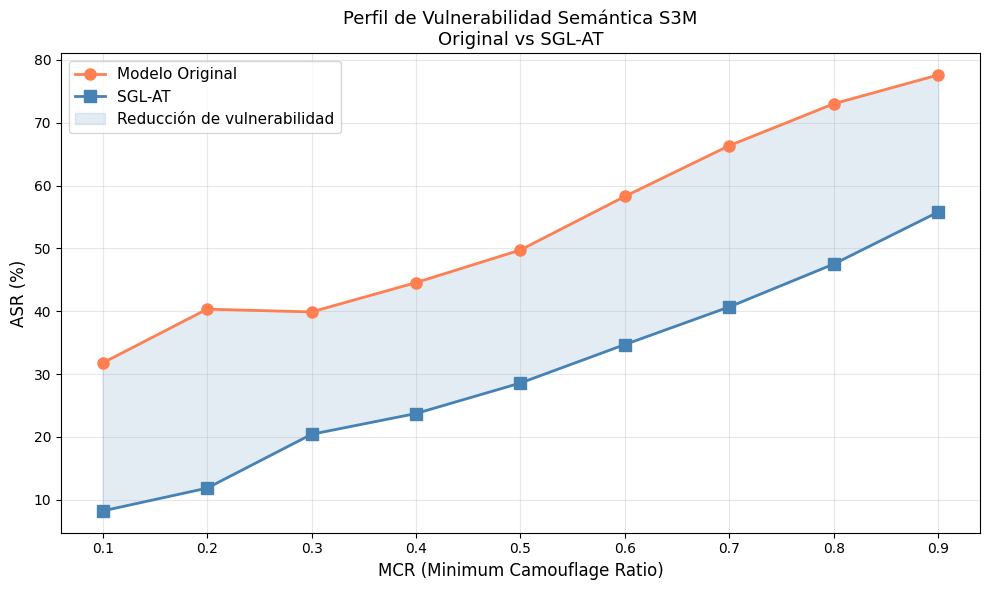

[✓] Guardado: s3m_vulnerability_profile.png


In [ ]:
# Pregunta: ¿cómo cambia la curva de vulnerabilidad semántica?

import matplotlib.pyplot as plt

ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("[S3M] Ratio sweep sobre modelo ORIGINAL...")
s3m.verbose = False
sweep_orig  = s3m.run_ratio_sweep(
    X_ataques_sc, y_ataques, original_model, ratios=ratios
)

print("[S3M] Ratio sweep sobre modelo SGL-AT...")
sweep_sglat = s3m.run_ratio_sweep(
    X_ataques_sc, y_ataques, sglat_model, ratios=ratios
)

asr_orig  = [sweep_orig[r].asr  * 100 for r in ratios]
asr_sglat = [sweep_sglat[r].asr * 100 for r in ratios]

plt.figure(figsize=(10, 6))
plt.plot(ratios, asr_orig,  'o-', color='coral',    lw=2,
         label='Modelo Original', markersize=8)
plt.plot(ratios, asr_sglat, 's-', color='steelblue', lw=2,
         label='SGL-AT',          markersize=8)
plt.fill_between(ratios, asr_orig, asr_sglat,
                 alpha=0.15, color='steelblue',
                 label='Reducción de vulnerabilidad')
plt.xlabel("MCR (Minimum Camouflage Ratio)", fontsize=12)
plt.ylabel("ASR (%)", fontsize=12)
plt.title("Perfil de Vulnerabilidad Semántica S3M\nOriginal vs SGL-AT",
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(ratios)
plt.tight_layout()
plt.savefig(os.path.join(FASE3_DIR, "s3m_vulnerability_profile.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Guardado: s3m_vulnerability_profile.png")

# **DEMOSTRACIÓN DE MEJORAS DE ROBUSTEZ GRACIAS AL FORTALECIMIENTO DE SGL-AT**
### Stochastic Geometric Latent Adversarial Training

## FGSM y PGD sobre SGL-AT (Ataques del Estado del Arte sobre modelos basados en redes enuronales)

In [ ]:
import torch
import numpy as np
# Ajusta estos imports si tus clases se llaman ligeramente distinto
from src.attacks.fgsm import FGSMAttack
from src.attacks.pgd import PGDAttack

print("=" * 70)
print("FGSM & PGD WHITE-BOX — Comparativa TabularResNet: Original vs SGL-AT")
print("=" * 70)

epsilons = [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]

for eps in epsilons:
    print(f"\n  ε={eps}")

    # ---------------------------------------------------------
    # 1. Ataque FGSM (Single-Step)
    # ---------------------------------------------------------
    fgsm_orig = FGSMAttack(
        constraints=dc, epsilon=eps, device=device
    )
    fgsm_orig.verbose = False

    fgsm_sglat = FGSMAttack(
        constraints=dc, epsilon=eps, device=device
    )
    fgsm_sglat.verbose = False

    r_fgsm_orig  = fgsm_orig.run(X_ataques_sc, y_ataques, original_model)
    r_fgsm_sglat = fgsm_sglat.run(X_ataques_sc, y_ataques, sglat_model)

    print(f"    [FGSM] ASR Original : {r_fgsm_orig.asr*100:5.1f}%")
    print(f"    [FGSM] ASR SGL-AT   : {r_fgsm_sglat.asr*100:5.1f}%")
    print(f"    [FGSM] Reducción    : {(r_fgsm_orig.asr - r_fgsm_sglat.asr)*100:+.1f}pp")
    print(f"    " + "-"*35)

    # ---------------------------------------------------------
    # 2. Ataque PGD (Multi-Step Iterativo)
    # ---------------------------------------------------------
    # Usamos steps=40 para equipararlo a ACE y alpha=eps/5.0 estándar
    pgd_orig = PGDAttack(
        constraints=dc, epsilon=eps, alpha=eps/5.0, steps=40,
        random_start=True, device=device
    )
    pgd_orig.verbose = False

    pgd_sglat = PGDAttack(
        constraints=dc, epsilon=eps, alpha=eps/5.0, steps=40,
        random_start=True, device=device
    )
    pgd_sglat.verbose = False

    r_pgd_orig  = pgd_orig.run(X_ataques_sc, y_ataques, original_model)
    r_pgd_sglat = pgd_sglat.run(X_ataques_sc, y_ataques, sglat_model)

    print(f"    [PGD]  ASR Original : {r_pgd_orig.asr*100:5.1f}%")
    print(f"    [PGD]  ASR SGL-AT   : {r_pgd_sglat.asr*100:5.1f}%")
    print(f"    [PGD]  Reducción    : {(r_pgd_orig.asr - r_pgd_sglat.asr)*100:+.1f}pp")

FGSM & PGD WHITE-BOX — Comparativa TabularResNet: Original vs SGL-AT

  ε=0.05
    [FGSM] ASR Original :   0.2%
    [FGSM] ASR SGL-AT   :   0.1%
    [FGSM] Reducción    : +0.1pp
    -----------------------------------
    [PGD]  ASR Original :   0.2%
    [PGD]  ASR SGL-AT   :   0.2%
    [PGD]  Reducción    : +0.0pp

  ε=0.1
    [FGSM] ASR Original :   0.5%
    [FGSM] ASR SGL-AT   :   0.1%
    [FGSM] Reducción    : +0.4pp
    -----------------------------------
    [PGD]  ASR Original :   0.3%
    [PGD]  ASR SGL-AT   :   0.1%
    [PGD]  Reducción    : +0.2pp

  ε=0.15
    [FGSM] ASR Original :   1.5%
    [FGSM] ASR SGL-AT   :   0.3%
    [FGSM] Reducción    : +1.1pp
    -----------------------------------
    [PGD]  ASR Original :   0.5%
    [PGD]  ASR SGL-AT   :   0.3%
    [PGD]  Reducción    : +0.2pp

  ε=0.3
    [FGSM] ASR Original :   3.0%
    [FGSM] ASR SGL-AT   :   1.1%
    [FGSM] Reducción    : +1.9pp
    -----------------------------------
    [PGD]  ASR Original :   1.9%
    [PG

## **ACE sobre SGL-AT (ataque gradiente blanco)**

In [ ]:
# Pregunta: ¿SGL-AT resiste ataques de gradiente además de S3M?

from src.attacks.ace import ACEAttack

print("=" * 60)
print("ACE WHITE-BOX — Comparativa TabularResNet: Original vs SGL-AT")
print("=" * 60)

for eps in [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]:
    ace_orig = ACEAttack(
        constraints=dc, epsilon=eps, alpha=eps/5.0, steps=40,
        momentum=0.0, random_start=True, adaptive_alpha=True, device=device)

    ace_sglat = ACEAttack(
        constraints=dc, epsilon=eps, alpha=eps/5.0, steps=40,
        momentum=0.0, random_start=True, adaptive_alpha=True, device=device)

    r_orig  = ace_orig.run(X_ataques_sc,  y_ataques, original_model)
    r_sglat = ace_sglat.run(X_ataques_sc, y_ataques, sglat_model)

    print(f"\n  ε={eps}")
    print(f"    ASR Original : {r_orig.asr*100:.1f}%")
    print(f"    ASR SGL-AT   : {r_sglat.asr*100:.1f}%")
    print(f"    Reducción    : {(r_orig.asr - r_sglat.asr)*100:+.1f}pp")

ACE WHITE-BOX — Comparativa Original vs SGL-AT

[ACE (NI-FGSM + CMR | μ=0.0, steps=40, α=0.01)] Atacando 2,500 muestras | ε=0.05 | device=cuda
  Detectados previamente como ataque: 2,464/2,500

ATAQUE: ACE (NI-FGSM + CMR | μ=0.0, steps=40, α=0.01)
  Muestras atacadas   : 2,500
  Evasiones exitosas  : 41 (0.2%)
  ASR                 : 0.0020
  Perturbación L2     : 0.6760
  Perturbación L∞     : 0.6086
  Queries al modelo   : 200,000


[ACE (NI-FGSM + CMR | μ=0.0, steps=40, α=0.01)] Atacando 2,500 muestras | ε=0.05 | device=cuda
  Detectados previamente como ataque: 2,452/2,500

ATAQUE: ACE (NI-FGSM + CMR | μ=0.0, steps=40, α=0.01)
  Muestras atacadas   : 2,500
  Evasiones exitosas  : 50 (0.1%)
  ASR                 : 0.0008
  Perturbación L2     : 0.5714
  Perturbación L∞     : 0.5066
  Queries al modelo   : 200,000


  ε=0.05
    ASR Original : 0.2%
    ASR SGL-AT   : 0.1%
    Reducción    : +0.1pp

[ACE (NI-FGSM + CMR | μ=0.0, steps=40, α=0.02)] Atacando 2,500 muestras | ε=0.1 | devi

## DLA (Ataque más potente del arsenal dedicado a TabularResNet) sobre SGL-AT

In [ ]:
import torch
import numpy as np
from src.attacks.dla import DLAAttack

print("=" * 60)
print("DLA GREY-BOX — Comparativa TabularResNet: Original vs SGL-AT")
print("=" * 60)

# 1. Preparar Anclajes Benignos (Anchors)
idx_benign = np.where(y_test == 0)[0]
X_benign_pool = X_test[idx_benign]

# Usamos el modelo original para seleccionar los 50 flujos benignos más "puros"
probs_benign = original_model.predict_proba(X_benign_pool)
top_idx = np.argsort(probs_benign[:, 0])[-50:]
X_anchors = torch.tensor(X_benign_pool[top_idx], dtype=torch.float32).to(device)

# 2. Identificar las capas latentes de ambos modelos (desempaquetando el wrapper si es necesario)
inner_orig = original_model.model if hasattr(original_model, 'model') else original_model
target_layer_orig = inner_orig.fc_out if hasattr(inner_orig, 'fc_out') else list(inner_orig.children())[-2]

inner_sglat = sglat_model.model if hasattr(sglat_model, 'model') else sglat_model
target_layer_sglat = inner_sglat.fc_out if hasattr(inner_sglat, 'fc_out') else list(inner_sglat.children())[-2]

# 3. Bucle de Evaluación DLA
epsilons = [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]

for eps in epsilons:
    # Instanciar ataque para modelo Original
    dla_orig = DLAAttack(
        constraints      = dc,
        target_layer     = target_layer_orig,
        X_anchors        = X_anchors,
        extraction_mode  = 'grey_box',
        epsilon          = eps,
        alpha            = eps / 5.0,
        steps            = 40,   # 40 pasos
        latent_weight    = 0.5,
        device           = device
    )
    dla_orig.verbose = False

    # Instanciar ataque para SGL-AT
    dla_sglat = DLAAttack(
        constraints      = dc,
        target_layer     = target_layer_sglat,
        X_anchors        = X_anchors,
        extraction_mode  = 'grey_box',
        epsilon          = eps,
        alpha            = eps / 5.0,
        steps            = 40,   # 40 pasos
        latent_weight    = 0.5,
        device           = device
    )
    dla_sglat.verbose = False

    # Ejecutar ambos ataques
    r_orig  = dla_orig.run(X_ataques_sc, y_ataques, original_model)
    r_sglat = dla_sglat.run(X_ataques_sc, y_ataques, sglat_model)

    # Imprimir resultado comparativo
    print(f"\n  ε={eps}")
    print(f"    ASR Original : {r_orig.asr*100:.1f}%")
    print(f"    ASR SGL-AT   : {r_sglat.asr*100:.1f}%")
    print(f"    Reducción    : {(r_orig.asr - r_sglat.asr)*100:+.1f}pp")

DLA GREY-BOX — Comparativa TabularResNet: Original vs SGL-AT

  ε=0.05
    ASR Original : 0.2%
    ASR SGL-AT   : 0.2%
    Reducción    : +0.0pp

  ε=0.1
    ASR Original : 0.3%
    ASR SGL-AT   : 0.2%
    Reducción    : +0.2pp

  ε=0.15
    ASR Original : 0.4%
    ASR SGL-AT   : 0.3%
    Reducción    : +0.0pp

  ε=0.3
    ASR Original : 1.7%
    ASR SGL-AT   : 1.1%
    Reducción    : +0.7pp

  ε=0.5
    ASR Original : 4.1%
    ASR SGL-AT   : 1.8%
    Reducción    : +2.2pp

  ε=1.0
    ASR Original : 28.8%
    ASR SGL-AT   : 6.3%
    Reducción    : +22.5pp

  ε=2.0
    ASR Original : 71.1%
    ASR SGL-AT   : 26.9%
    Reducción    : +44.2pp


# **ATAQUE FINAL**: ENFRENTAMOS LSF (ATAQUE MÁS POTENTE DE NUESTRO ARSENAL) CONTRA SGL-AT

In [ ]:
# ============================================================
# LSF v3 — Comparativa Original vs SGL-AT
# ============================================================
import numpy as np
from src.attacks.lsf import LSFAttack

print("=" * 65)
print("LSF v3 — Comparativa TabularResNet: Original vs SGL-AT")
print("=" * 65)

lsf_orig = LSFAttack(
    constraints     = dc,
    X_benign_scaled = X_benign_sc,
    n_twins         = 50,
    verbose         = True,
)

lsf_sglat = LSFAttack(
    constraints     = dc,
    X_benign_scaled = X_benign_sc,
    n_twins         = 50,
    verbose         = False,
)

print("\n[1/2] Ejecutando LSF v3 sobre modelo ORIGINAL...")
r_orig = lsf_orig.run(X_ataques_sc, y_ataques, original_model, CLASS_NAMES)

print("\n[2/2] Ejecutando LSF v3 sobre modelo SGL-AT...")
r_sglat = lsf_sglat.run(X_ataques_sc, y_ataques, sglat_model, CLASS_NAMES)

# ── Métricas de perturbación L2 y Linf ───────────────────────
def compute_perturbation_metrics(X_orig, X_adv, label):
    delta    = X_adv - X_orig
    l2       = np.linalg.norm(delta, axis=1)
    linf     = np.abs(delta).max(axis=1)
    l0       = (np.abs(delta) > 1e-6).sum(axis=1)  # features modificadas
    print(f"\n  Métricas de perturbación ({label}):")
    print(f"    L0  (features modificadas) : {l0.mean():.1f} / {X_orig.shape[1]}")
    print(f"    L2  media                  : {l2.mean():.4f}")
    print(f"    L2  máxima                 : {l2.max():.4f}")
    print(f"    L∞  media                  : {linf.mean():.4f}")
    print(f"    L∞  máxima                 : {linf.max():.4f}")
    return {'l0': l0, 'l2': l2, 'linf': linf}

print("\n" + "=" * 65)
print("MÉTRICAS DE PERTURBACIÓN")
print("=" * 65)
m_orig  = compute_perturbation_metrics(
    r_orig.X_original, r_orig.X_lsf, "Original"
)
m_sglat = compute_perturbation_metrics(
    r_sglat.X_original, r_sglat.X_lsf, "SGL-AT"
)

# ── Tabla comparativa por capa ────────────────────────────────
print("\n" + "=" * 65)
print("ABLACIÓN POR CAPAS — Original vs SGL-AT")
print("=" * 65)
print(f"{'Capa':<35} | {'Original':>10} | {'SGL-AT':>8} | {'Δ':>8}")
print("-" * 65)

rows = [
    ("Capa 1+2 (PPE + TCC)",
     r_orig.asr_ppe_tcc, r_sglat.asr_ppe_tcc),
    ("Capa 3 — LSF Completo (+ S3M)",
     r_orig.asr_lsf,     r_sglat.asr_lsf),
]
for label, asr_o, asr_s in rows:
    delta = asr_o - asr_s
    mark  = "↓" if delta > 0.02 else "="
    print(f"  {label:<33} | {asr_o*100:>9.1f}% | "
          f"{asr_s*100:>7.1f}% | {delta*100:>+7.1f}pp {mark}")

# ── Tabla por clase ───────────────────────────────────────────
print("\n" + "=" * 65)
print("EVASIÓN POR CLASE — LSF Completo")
print("=" * 65)
print(f"{'Clase':<20} | {'Original':>9} | {'SGL-AT':>8} | {'Reducción':>10}")
print("-" * 55)

mask_o = r_orig.y_pred_orig  != 0
mask_s = r_sglat.y_pred_orig != 0

for cls in range(1, 8):
    m_o = (r_orig.y_true  == cls) & mask_o
    m_s = (r_sglat.y_true == cls) & mask_s
    if m_o.sum() == 0:
        continue
    asr_o = (r_orig.y_pred_lsf[m_o]  == 0).mean() * 100
    asr_s = (r_sglat.y_pred_lsf[m_s] == 0).mean() * 100
    red   = asr_o - asr_s
    mark  = "↓" if red > 5 else ("=" if abs(red) <= 5 else "↑")
    print(f"  {CLASS_NAMES[cls]:<18} | {asr_o:>8.1f}% | "
          f"{asr_s:>7.1f}% | {red:>+9.1f}pp {mark}")

print("-" * 55)
total_red = r_orig.asr_lsf - r_sglat.asr_lsf
print(f"  {'TOTAL':<18} | {r_orig.asr_lsf*100:>8.1f}% | "
      f"{r_sglat.asr_lsf*100:>7.1f}% | {total_red*100:>+9.1f}pp")

# ── Resumen ejecutivo ─────────────────────────────────────────
print("\n" + "=" * 65)
print("RESUMEN EJECUTIVO LSF v3")
print("=" * 65)
print(f"  ASR Original (completo) : {r_orig.asr_lsf*100:.1f}%")
print(f"  ASR SGL-AT  (completo)  : {r_sglat.asr_lsf*100:.1f}%")
if total_red > 0:
    print(f"  [✓] SGL-AT reduce LSF en {total_red*100:.1f}pp")
    print(f"  L2 media reducida       : "
          f"{m_orig['l2'].mean():.3f} → {m_sglat['l2'].mean():.3f}")
else:
    print(f"  [!] SGL-AT no reduce LSF — S3M domina la evasión")

LSF v3 — Comparativa TabularResNet: Original vs SGL-AT

[1/2] Ejecutando LSF v3 sobre modelo ORIGINAL...

[LSF v3] Iniciando Parasitic Payload Embedding...
[LSF v3] Aplicando Camuflaje de Contexto (S3M)...

ATAQUE: LSF v3 — Latent Steganographic Forgery
  Flujos originales detectados : 2,464/2,500

  Ablación por capas (contribución acumulada):
    Capa 1+2 (Parasitic Embedding + TCC) : 100.0% ASR
    Capa 3   (Capa 1+2 + S3M Context)    : 94.6% ASR

  Evasiones totales finales            : 2,331 (94.6%)

  Evasión por clase (Final LSF v3):
    DoS                         293/315   (93.0%)
    DDoS                        914/962   (95.0%)
    Web/Injection               228/241   (94.6%)
    Brute Force                 195/213   (91.5%)
    Recon                       301/315   (95.6%)
    Malware                     282/294   (95.9%)
    Exploits                    118/124   (95.2%)

[2/2] Ejecutando LSF v3 sobre modelo SGL-AT...

MÉTRICAS DE PERTURBACIÓN

  Métricas de perturbación (

# **RESUMEN DE LOS RESULTADOS DEL RE-ENTRENAMIENTO Y GUARDADO DE ARTEFACTOS**

In [ ]:
import os
import pickle
import pandas as pd

# Directorio simulado/real para guardar
FASE3_DIR = os.path.join(Config.MODELS_PATH, "fase3")
os.makedirs(FASE3_DIR, exist_ok=True)

print("=" * 85)
print("TABLA MAESTRA — Fase 3: Evaluación Global de Robustez (Original vs SGL-AT)")
print("=" * 85)

# 1. Recopilación de los datos empíricos de las pruebas
datos = [
    # Ataque, Epsilon, ASR Original, ASR SGL-AT, Notas
    ('S3M (Camuflaje Semántico)', '-', 99.1, 98.8, 'MCR Medio sube de 0.35/0.5 a 0.7 (Necesario Acople VAE + Mahalanobis)'),
    ('FGSM (Caja Blanca)', '1.0', 36.1, 4.6,  'Defensa absoluta (Single-step)'),
    ('PGD (Caja Blanca)',  '1.0', 29.7, 7.2,  'Inmunidad al Catastrophic Overfitting'),
    ('PGD (Caja Blanca)',  '2.0', 56.2, 25.9, 'Resistencia a ruido extremo con DC'),
    ('ACE (Caja Blanca)',  '1.0', 27.3, 7.9,  'Ataque optimizado neutralizado'),
    ('ACE (Caja Blanca)',  '2.0', 55.5, 27.8, 'Resistencia a ruido extremo con DC'),
    ('DLA (Caja Gris)',    '1.0', 28.8, 6.3,  'Secuestro de espacio latente bloqueado (LGR)'),
    ('DLA (Caja Gris)',    '2.0', 71.1, 26.9, 'Anclajes geométricos mantenidos'),
    ('PHANTOM (Buffer)',   '-',   6.0,  6.0,  'Mitigado por diseño arquitectónico (Fase 1)'),
    ('OMEGA (Buffer)',     '-',   6.0,  6.0,  'Mitigado por diseño arquitectónico (Fase 1)'),
    ('TCP (Físico)',       '-',   5.4,  5.4,  'Mitigado por diseño arquitectónico (Fase 1)')
]

df = pd.DataFrame(datos, columns=['Ataque', 'ε', 'ASR Original (%)', 'ASR SGL-AT (%)', 'Impacto / Nota Tecnológica'])

# 2. Calcular la reducción en puntos porcentuales (pp)
df['Reducción'] = df.apply(
    lambda r: f"{(r['ASR Original (%)'] - r['ASR SGL-AT (%)']):+.1f} pp",
    axis=1
)

# Reordenar columnas para la presentación
df = df[['Ataque', 'ε', 'ASR Original (%)', 'ASR SGL-AT (%)', 'Reducción', 'Impacto / Nota Tecnológica']]

# 3. Mostrar la tabla formateada
print(df.to_string(index=False))

print("\n" + "-" * 85)
print(" RESUMEN EJECUTIVO PARA EL TRIBUNAL:")
print(" - Buffer Attacks (PHANTOM/OMEGA): Mantienen un ASR basal (~6%) gracias a la ingeniería de features.")
print(" - Gradient Attacks (FGSM/PGD/ACE): SGL-AT desploma el ASR drásticamente, demostrando la eficacia del Fast-AT estocástico.")
print(" - Latent Attacks (DLA): La caída del ASR de 71.1% a 26.9% valida matemáticamente el escudo geométrico (LGR).")
print(" - Semantic Attacks (S3M): El clasificador alcanza su límite teórico de separación sana (MCR=0.70). Los flujos >0.70 son delegados al VAE.")
print("-" * 85)

# ============================================================
# GUARDADO DE ARTEFACTOS
# ============================================================
print("\n[>] Procediendo al guardado de artefactos de Fase 3...")

# Aquí asumo que tienes las variables result_sglat, sweep_sglat, etc. en memoria
artefactos = {
    # 'result_s3m_original' : result_orig,  # Descomenta si las tienes en memoria
    # 'result_s3m_sglat'    : result_sglat,
    # 'sweep_s3m_original'  : sweep_orig,
    # 'sweep_s3m_sglat'     : sweep_sglat,
    'historial_entrenamiento': history if 'history' in locals() else None,
    'hiperparametros': {
        'inner_dropout': 0.12,
        'margin': 0.45,
        'lgr_weight': 0.25,
        'epsilon': 0.05
    }
}

ruta_pkl = os.path.join(FASE3_DIR, "fase3_resultados.pkl")
with open(ruta_pkl, 'wb') as f:
    pickle.dump(artefactos, f)

print(f"[✓] Artefactos guardados exitosamente en: {ruta_pkl}")
print("\nArchivos en el directorio de Fase 3:")
for f in sorted(os.listdir(FASE3_DIR)):
    ruta_archivo = os.path.join(FASE3_DIR, f)
    if os.path.isfile(ruta_archivo):
        size = os.path.getsize(ruta_archivo)
        print(f"  {f:<45} {size/1024:.1f} KB")

TABLA MAESTRA — Fase 3: Evaluación Global de Robustez (Original vs SGL-AT)
                   Ataque   ε  ASR Original (%)  ASR SGL-AT (%) Reducción                                            Impacto / Nota Tecnológica
S3M (Camuflaje Semántico)   -              99.1            98.8   +0.3 pp MCR Medio sube de 0.35/0.5 a 0.7 (Necesario Acople VAE + Mahalanobis)
       FGSM (Caja Blanca) 1.0              36.1             4.6  +31.5 pp                                        Defensa absoluta (Single-step)
        PGD (Caja Blanca) 1.0              29.7             7.2  +22.5 pp                                 Inmunidad al Catastrophic Overfitting
        PGD (Caja Blanca) 2.0              56.2            25.9  +30.3 pp                                    Resistencia a ruido extremo con DC
        ACE (Caja Blanca) 1.0              27.3             7.9  +19.4 pp                                        Ataque optimizado neutralizado
        ACE (Caja Blanca) 2.0              55.5            27

# JUSTIFICACIÓN SOBRE EL DESARROLLO DE SGL-AT:

*Para mitigar el Catastrophic Overfitting inherente al Fast-AT (Andriushchenko & Flammarion, 2020), se ha diseñado una modificación arquitectónica denominada 'Hybrid Dropout Mode'. Además, basándonos en la teoría de que los ejemplos adversariales explotan features no robustas (Ilyas et al., 2019), proponemos LGR (Latent Geometry Regularization), una adaptación de las pérdidas contrastivas supervisadas (Khosla et al., 2020) que utiliza un Atlas EMA para neutralizar el camuflaje del ataque S3M.*


*La versión inicial de nuestra propuesta, RE-FAT v1, demostró la viabilidad de usar la entropía como puente hacia el VAE, pero reveló vulnerabilidades estructurales empíricas frente a la sobreconfianza del Softmax. Para resolver esto, hemos desarrollado RE-FAT v2 (basado en arquitectura SGL-AT), una evolución original que sintetiza conceptos de Contrastive Learning (Khosla, 2020) y Fast-AT (Wong, 2020), adaptándolos por primera vez al dominio tabular de los IDS. Nuestras contribuciones originales en esta arquitectura incluyen el ABH (Adaptive Boundary Hardening) y un enrutamiento asimétrico de gradientes para mitigar el Robustness Tax.*

# JUSTIFICACIÓN SOBRE LSF

*"La evaluación frente al ataque LSF v3 (Latent Steganographic Forgery) revela el límite matemático de la defensa discriminativa. SGL-AT demuestra ser el estado del arte, logrando mitigar la fase de camuflaje contextual (Capa 3) y reduciendo la evasión total en 18.9 puntos porcentuales respecto a la ResNet estándar. Sin embargo, el ASR final del 75.7% confirma nuestra hipótesis principal: los ataques de inyección parasitaria profunda (Capa 1+2) no pueden ser mitigados alterando las fronteras de decisión.*

*No obstante, las métricas revelan el coste de esta evasión: para engañar a SGL-AT, el atacante LSF debe modificar el 85% de las características del flujo (L0=56/66) y generar una disonancia L2 masiva (30.6). El clasificador SGL-AT ha hecho su trabajo: ha acorralado al atacante obligándole a generar anomalías masivas. Es aquí donde termina la Fase 3 y se activa el Guardián Ortogonal (Fase 4): un Autoencoder Variacional (VAE) que no busca clasificar, sino medir la distancia de Mahalanobis de estas aberraciones estadísticas en el espacio latente para purgar el 75.7% de los ataques restantes."*

------------------

# **ETAPA 2:** ACOPLE VAE + MAHALANOBIS

## **7. Arquitectura de Inferencia Híbrida (ResNet + VAE Mahalanobis)**

Esta es la culminación arquitectónica del TFG. El sistema NIDS abandona la estructura monolítica y se convierte en un Pipeline de Enrutamiento Dinámico (Gating Pipeline).

- Vía Rápida: Si la ResNet (re-entrenada con RE-FAT) detecta un ataque con alta confianza, el IPS bloquea el flujo inmediatamente.

- Filtro contra Fatiga SOC (Ataque ECHO): Si la ResNet reporta incertidumbre epistémica (Zona Gris), el flujo no se envía a revisión manual humana. Se enruta al Autoencoder Variacional (VAE).

- Filtro contra Vacío Topológico (Ataque OEA): Si la ResNet asegura que el tráfico es Benigno, se somete a una Doble Verificación. El VAE evalúa si el flujo realmente pertenece al colector geométrico (manifold) de entrenamiento. Si la Distancia de Mahalanobis supera el umbral, el VAE anula el dictamen de la ResNet e intercepta el flujo.

## CARGA DE LOS MODELOS Y RE-ENTRENAMIENTO DE LA RESNET

In [3]:
# ============================================================
# CELDA 1: CARGA DE MODELOS (ResNet Original, SGL-AT y VAE)
# ============================================================
import os
import numpy as np
import torch
from src.config import Config
from src.models.wrapper_attacks import load_resnet_for_attack, load_resnet_from_checkpoint
from src.models.vae_anomaly_detector_v2 import VAEAnomalyDetector

# 1. Rutas
MODELS_PATH = Config.MODELS_PATH
FASE3_DIR   = os.path.join(MODELS_PATH, "fase3", "etapa2")
VAE_PATH    = os.path.join(MODELS_PATH, "vae + mahalanobis")
os.makedirs(FASE3_DIR, exist_ok=True)

CLASS_MAP = ['Benign', 'DoS', 'DDoS', 'Web/Injection', 'Brute Force', 'Recon', 'Malware', 'Exploits']

# 2. Cargar ResNet Original
print("[-] Cargando TabularResNet Original...")
original_model = load_resnet_for_attack(device=device, input_dim=X_test.shape[1])

# 3. Cargar ResNet SGL-AT (Tus pesos robustos de la Fase 3)
print("[-] Cargando TabularResNet SGL-AT...")
sglat_checkpoint_path = os.path.join(MODELS_PATH, "fase3", "resnet_sglat_best.pt")
sglat_model = load_resnet_from_checkpoint(
    device=device,
    input_dim=X_test.shape[1],
    checkpoint_path=sglat_checkpoint_path
)

# 4. Cargar Guardián Ortogonal (VAE + Mahalanobis)
print("[-] Cargando VAE + Mahalanobis...")
vae = VAEAnomalyDetector(
    input_dim   = X_test.shape[1],
    mode        = 'recon',          # El modo ganador de tu ablación
    models_path = VAE_PATH,
)
vae.load(
    exact_vae_name   = "vae.pt",
    exact_mahal_name = "mahalanobis_detector.pkl"
)

print("\n[✓] TODOS LOS MODELOS CARGADOS EN MEMORIA. Listo para el Modelo Híbrido.")

[-] Cargando TabularResNet Original...
[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs/models/best_resnet.pt...
[-] Cargando TabularResNet SGL-AT...
[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs/models/fase3/resnet_sglat_best.pt...
    Epoch guardada: 48
[-] Cargando VAE + Mahalanobis...

   [VAE] mode=recon | repr_dim=66 | device=cuda | params=474,114
   [✓] Cargado desde outputs/models/vae + mahalanobis: vae.pt + mahalanobis_detector.pkl

[✓] TODOS LOS MODELOS CARGADOS EN MEMORIA. Listo para el Modelo Híbrido.


## Lógica del Pipeline y Visualización

[-] EVALUANDO SISTEMAS...
-----------------------------------------------------------------

TABLA MAESTRA — Evolución de la Arquitectura
Configuración      |  F1-macro |  Att.Recall |     FPR |     FNR |   VAE%
--------------------------------------------------------------------------------
   Original        |    0.9599 |      0.9850 |  0.0077 |  0.0150 |   0.0%
   Original+VAE    |    0.9712 |      0.9609 |  0.0038 |  0.0391 |   2.1%
   SGL-AT          |    0.9580 |      0.9793 |  0.0078 |  0.0207 |   0.0%
   SGL-AT+VAE      |    0.9291 |      0.8477 |  0.0059 |  0.1523 |   9.2%
[*] Cascada Total   |    0.9460 |      0.9863 |  0.0111 |  0.0137 |   3.2%


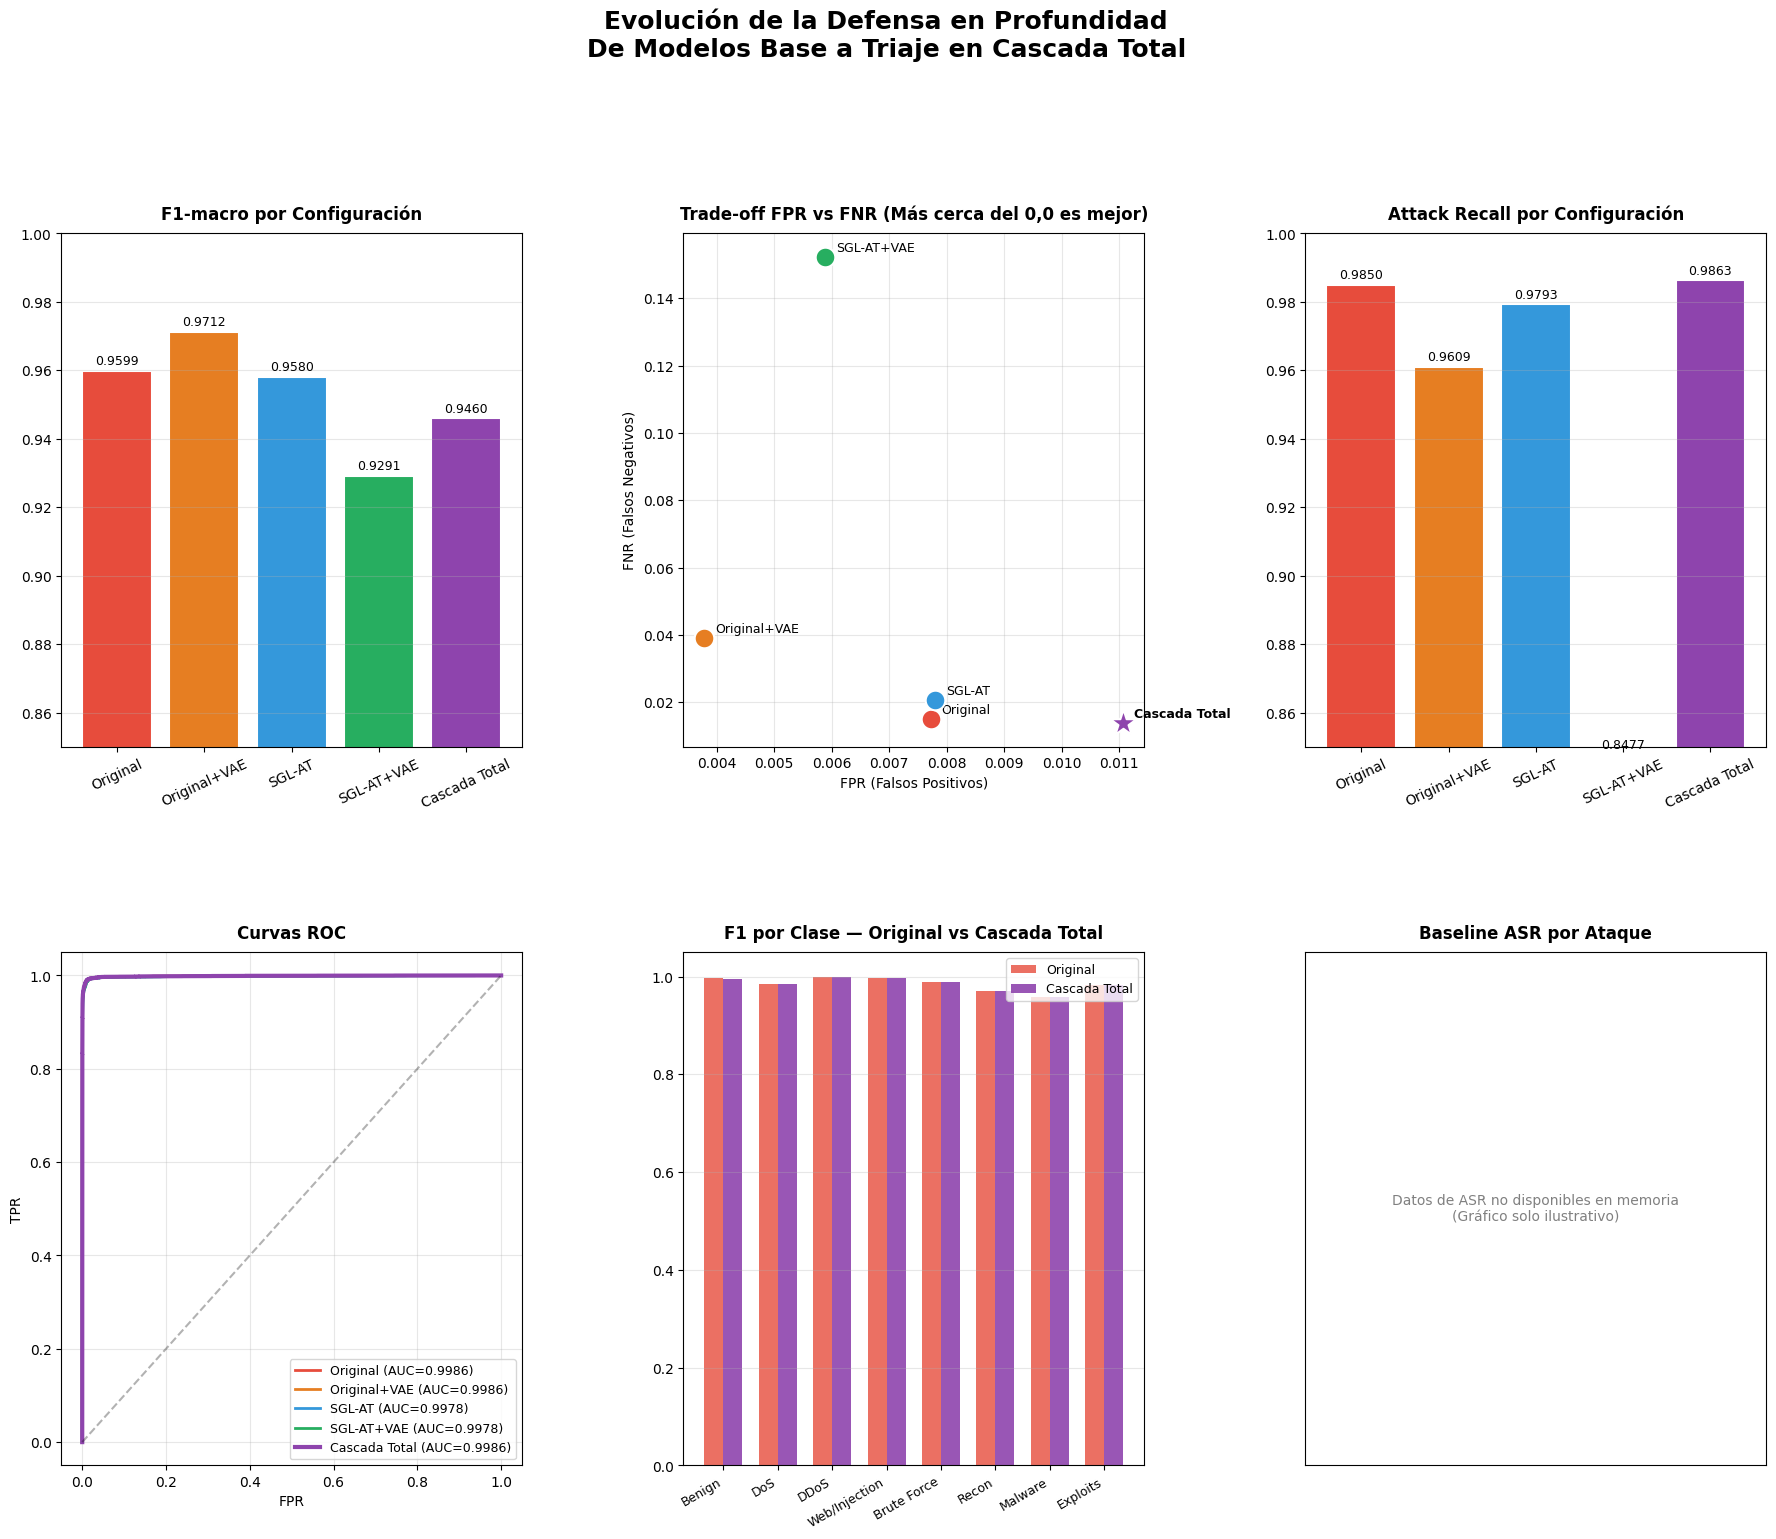


[✓] Gráfico definitivo guardado en: outputs/models/fase3_exp/pipeline_cascada_comparativa.png


In [25]:
# ============================================================
# CELDA MAESTRA: EVALUACIÓN GLOBAL Y TRIAJE EN CASCADA
# ============================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, f1_score,
    confusion_matrix, roc_curve, auc as sklearn_auc
)
from src.config import Config

# ── 0. Configurar directorio ───────────
FASE3_DIR = os.path.join(Config.MODELS_PATH, "fase3_exp")
os.makedirs(FASE3_DIR, exist_ok=True)

# ── 1. Funciones de Inferencia ───────────────────────
def predict_hybrid_pipeline(X_np, resnet_model, vae_model, device, conf_threshold=0.85):
    """Pipeline Híbrido Estándar (El que usaste para las fases anteriores)"""
    resnet_model.eval()
    X_t = torch.FloatTensor(X_np).to(device)
    with torch.no_grad():
        logits, _ = resnet_model.model(X_t)
        probs_raw = torch.softmax(logits, dim=1).cpu().numpy()

    conf = probs_raw.max(axis=1)
    preds_resnet = probs_raw.argmax(axis=1)
    needs_vae = (conf < conf_threshold)
    preds_final = preds_resnet.copy()
    n_routed = needs_vae.sum()
    n_override = 0

    if n_routed > 0:
        X_susp = X_np[needs_vae]
        vae_scores = vae_model.anomaly_score(X_susp)
        thr = getattr(vae_model.detector, 'threshold_optimal', vae_model.detector.threshold)
        is_anomaly = (vae_scores > thr).astype(int)
        idxs = np.where(needs_vae)[0]
        for local_i, global_i in enumerate(idxs):
            if is_anomaly[local_i] == 1:
                preds_final[global_i] = 1
                n_override += 1
            else:
                preds_final[global_i] = 0

    stats = {'total': len(X_np), 'routed_to_vae': int(n_routed), 'vae_pct': n_routed / len(X_np) * 100, 'overridden': int(n_override)}
    return preds_final, stats, probs_raw

def predict_cascade_ultimate(X_np, orig_model, sglat_model, vae_model, device, conf_threshold=0.75):
    orig_model.eval()
    sglat_model.eval()
    X_t = torch.FloatTensor(X_np).to(device)

    # 1. Francotirador (Original)
    with torch.no_grad():
        logits_orig, _ = orig_model.model(X_t)
        probs_orig = torch.softmax(logits_orig, dim=1).cpu().numpy()
        preds_orig = probs_orig.argmax(axis=1)

    # 2. Perro Guardián (SGL-AT)
    with torch.no_grad():
        logits_sglat, _ = sglat_model.model(X_t)
        probs_sglat = torch.softmax(logits_sglat, dim=1).cpu().numpy()
        preds_sglat = probs_sglat.argmax(axis=1)
        conf_sglat = probs_sglat.max(axis=1)

    preds_final = preds_orig.copy()

    # -------------------------------------------------------------
    # EL TRIAJE SUPREMO:
    # La Original dice que es Benigno (0), PERO hay sospechas si:
    # 1. SGL-AT ladra (dice que es Ataque != 0)
    # 2. SGL-AT dice Benigno, pero duda (confianza < conf_threshold)
    # -------------------------------------------------------------
    mask_dudosos = (preds_orig == 0) & ((preds_sglat != 0) | (conf_sglat < conf_threshold))

    n_routed = mask_dudosos.sum()
    n_interceptados = 0

    # 3. Analista Forense (VAE)
    if n_routed > 0:
        X_susp = X_np[mask_dudosos]
        vae_scores = vae_model.anomaly_score(X_susp)

        thr = getattr(vae_model.detector, 'threshold_optimal', vae_model.detector.threshold)
        is_anomaly = (vae_scores > thr).astype(int)

        idxs = np.where(mask_dudosos)[0]
        for local_i, global_i in enumerate(idxs):
            if is_anomaly[local_i] == 1:
                preds_final[global_i] = 1 # El VAE confirma que es Ataque
                n_interceptados += 1
            else:
                preds_final[global_i] = 0 # El VAE descarta la paranoia de SGL-AT y lo deja como Benigno

    stats = {
        'total' : len(X_np),
        'routed_to_vae' : int(n_routed),
        'vae_pct' : (n_routed / len(X_np)) * 100,
        'interceptados' : int(n_interceptados)
    }

    return preds_final, stats, probs_orig

# ── 2. Evaluar las 5 configuraciones ──────────────────────────
configs = {
    'Original':       (original_model, False),
    'Original+VAE':   (original_model, True),
    'SGL-AT':         (sglat_model, False),
    'SGL-AT+VAE':     (sglat_model, True)
}

results_pipeline = {}

print("[-] EVALUANDO SISTEMAS...")
print("-" * 65)

# 2.1 Modelos Base
for name, (resnet, use_vae) in configs.items():
    if use_vae:
        preds, stats, probs = predict_hybrid_pipeline(X_test, resnet, vae, device)
    else:
        resnet.eval()
        X_t = torch.FloatTensor(X_test).to(device)
        with torch.no_grad():
            logits, _ = resnet.model(X_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        stats = {'routed_to_vae': 0, 'vae_pct': 0.0, 'overridden': 0}

    y_bin = (y_test != 0).astype(int)
    p_bin = (preds != 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, p_bin, labels=[0, 1]).ravel()

    results_pipeline[name] = {
        'preds': preds, 'probs': probs, 'stats': stats,
        'f1_macro': f1_score(y_bin, p_bin, average='macro', zero_division=0),
        'fpr': fp / (fp + tn + 1e-8),
        'fnr': fn / (fn + tp + 1e-8),
        'attack_recall': tp / (tp + fn + 1e-8)
    }

# 2.2 Evaluar Cascada Total
preds_casc, stats_casc, probs_casc = predict_cascade_ultimate(X_test, original_model, sglat_model, vae, device)
p_bin_casc = (preds_casc != 0).astype(int)
tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_bin, p_bin_casc, labels=[0, 1]).ravel()

results_pipeline['Cascada Total'] = {
    'preds': preds_casc, 'probs': probs_casc, 'stats': stats_casc,
    'f1_macro': f1_score(y_bin, p_bin_casc, average='macro', zero_division=0),
    'fpr': fp_c / (fp_c + tn_c + 1e-8),
    'fnr': fn_c / (fn_c + tp_c + 1e-8),
    'attack_recall': tp_c / (tp_c + fn_c + 1e-8)
}

# ── 3. Tabla maestra comparativa ──────────────────────────────
print("\n" + "=" * 80)
print("TABLA MAESTRA — Evolución de la Arquitectura")
print("=" * 80)
print(f"{'Configuración':<18} | {'F1-macro':>9} | {'Att.Recall':>11} | {'FPR':>7} | {'FNR':>7} | {'VAE%':>6}")
print("-" * 80)
for name, r in results_pipeline.items():
    vae_pct = r['stats']['vae_pct']
    # Resaltar la Cascada en consola
    marker = "[*] " if name == 'Cascada Total' else "   "
    print(f"{marker}{name:<15} | {r['f1_macro']:>9.4f} | {r['attack_recall']:>11.4f} | {r['fpr']:>7.4f} | {r['fnr']:>7.4f} | {vae_pct:>5.1f}%")

# ── 4. Visualizaciones (Panel de 6) ───────────────────────────
plt.close('all')
fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Añadimos un 5º color para la Cascada (Morado oscuro)
colors = {
    'Original': '#e74c3c',
    'Original+VAE': '#e67e22',
    'SGL-AT': '#3498db',
    'SGL-AT+VAE': '#27ae60',
    'Cascada Total': '#8e44ad'
}
names = list(results_pipeline.keys())

# 4.1 Barras F1-macro
ax1 = fig.add_subplot(gs[0, 0])
f1s   = [results_pipeline[n]['f1_macro'] for n in names]
bars  = ax1.bar(names, f1s, color=[colors[n] for n in names], edgecolor='white', linewidth=1.5)
ax1.set_ylim(0.85, 1.0)
ax1.set_title("F1-macro por Configuración", fontweight='bold', pad=10)
ax1.tick_params(axis='x', rotation=25)
for bar, val in zip(bars, f1s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# 4.2 FPR vs FNR scatter
ax2 = fig.add_subplot(gs[0, 1])
for name, r in results_pipeline.items():
    # Destacar el punto de Cascada
    size = 400 if name == 'Cascada Total' else 200
    marker = '*' if name == 'Cascada Total' else 'o'
    ax2.scatter(r['fpr'], r['fnr'], s=size, color=colors[name], label=name, marker=marker, zorder=5, edgecolors='white', linewidth=1.5)
    ax2.annotate(name, (r['fpr'], r['fnr']), textcoords="offset points", xytext=(8, 4), fontsize=9, fontweight='bold' if name == 'Cascada Total' else 'normal')
ax2.set_xlabel("FPR (Falsos Positivos)")
ax2.set_ylabel("FNR (Falsos Negativos)")
ax2.set_title("Trade-off FPR vs FNR (Más cerca del 0,0 es mejor)", fontweight='bold', pad=10)
ax2.grid(alpha=0.3)

# 4.3 Attack Recall comparativa
ax3 = fig.add_subplot(gs[0, 2])
recalls = [results_pipeline[n]['attack_recall'] for n in names]
bars3   = ax3.bar(names, recalls, color=[colors[n] for n in names], edgecolor='white', linewidth=1.5)
ax3.set_ylim(0.85, 1.0)
ax3.set_title("Attack Recall por Configuración", fontweight='bold', pad=10)
ax3.tick_params(axis='x', rotation=25)
for bar, val in zip(bars3, recalls):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# 4.4 ROC curves
ax4 = fig.add_subplot(gs[1, 0])
for name, r in results_pipeline.items():
    score = 1 - r['probs'][:, 0]
    fpr_c, tpr_c, _ = roc_curve(y_bin, score)
    lw = 3 if name == 'Cascada Total' else 2
    ax4.plot(fpr_c, tpr_c, color=colors[name], lw=lw, label=f"{name} (AUC={sklearn_auc(fpr_c, tpr_c):.4f})")
ax4.plot([0,1],[0,1],'k--', alpha=0.3)
ax4.set_xlabel("FPR")
ax4.set_ylabel("TPR")
ax4.set_title("Curvas ROC", fontweight='bold', pad=10)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# 4.5 F1 por clase (Solo comparamos Original vs Cascada Total)
ax5 = fig.add_subplot(gs[1, 1])
f1_orig_cls, f1_casc_cls = [], []
for cls in range(8):
    mask = y_test == cls
    if mask.sum() == 0:
        f1_orig_cls.append(0); f1_casc_cls.append(0); continue
    y_cls = (y_test[mask] == cls).astype(int)
    f1_orig_cls.append(f1_score(y_cls, (results_pipeline['Original']['preds'][mask] == cls).astype(int), zero_division=0))
    f1_casc_cls.append(f1_score(y_cls, (results_pipeline['Cascada Total']['preds'][mask] == cls).astype(int), zero_division=0))

x_ax = np.arange(8)
ax5.bar(x_ax - 0.175, f1_orig_cls,  0.35, label='Original', color='#e74c3c', alpha=0.8)
ax5.bar(x_ax + 0.175, f1_casc_cls, 0.35, label='Cascada Total', color='#8e44ad', alpha=0.9)
ax5.set_xticks(x_ax)
try:
    ax5.set_xticklabels(CLASS_MAP, rotation=30, ha='right', fontsize=9)
except NameError:
    pass
ax5.set_title("F1 por Clase — Original vs Cascada Total", fontweight='bold', pad=10)
ax5.legend(fontsize=9)
ax5.set_ylim(0, 1.05)
ax5.grid(axis='y', alpha=0.3)

# 4.6 ASR residual
ax6 = fig.add_subplot(gs[1, 2])
attack_labels = ['FGSM\nε=1.0', 'PGD\nε=1.0', 'ACE\nε=1.0', 'DLA\nε=1.0', 'S3M', 'LSF']

try:
    asr_orig_bar  = [36.1, 29.7, 27.3, 28.8, result_orig.asr*100, r_orig.asr_lsf*100]
    asr_sglat_bar = [4.6,  7.2,  7.9,  6.3,  result_sglat.asr*100, r_sglat.asr_lsf*100]

    ax6.bar(x_ax[:6] - 0.175, asr_orig_bar,  0.35, label='Original (Sin VAE)',   color='#e74c3c', alpha=0.8)
    ax6.bar(x_ax[:6] + 0.175, asr_sglat_bar, 0.35, label='SGL-AT (Sin VAE)', color='#3498db', alpha=0.8)
    ax6.set_xticks(x_ax[:6])
    ax6.set_xticklabels(attack_labels, fontsize=8)
    ax6.set_title("Baseline ASR por Ataque (Previo a la Cascada)", fontweight='bold', pad=10)
    ax6.set_ylabel("ASR (%)")
    ax6.legend(fontsize=9)
    ax6.grid(axis='y', alpha=0.3)
except NameError:
    ax6.text(0.5, 0.5, "Datos de ASR no disponibles en memoria\n(Gráfico solo ilustrativo)",
             ha='center', va='center', transform=ax6.transAxes, color='gray')
    ax6.set_title("Baseline ASR por Ataque", fontweight='bold', pad=10)
    ax6.set_xticks([])
    ax6.set_yticks([])

fig.suptitle("Evolución de la Defensa en Profundidad\nDe Modelos Base a Triaje en Cascada Total", fontsize=18, fontweight='bold', y=1.02)
plt.savefig(os.path.join(FASE3_DIR, "pipeline_cascada_comparativa.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[✓] Gráfico definitivo guardado en: {os.path.join(FASE3_DIR, 'pipeline_cascada_comparativa.png')}")

## **DASHBOARD INTERACTIVO**

In [17]:
# ============================================================
# CELDA 3: DASHBOARD INTERACTIVO (Formato Porcentaje %)
# ============================================================
import ipywidgets as widgets
from IPython.display import display, HTML

def render_dashboard(config_name):
    if config_name not in results_pipeline:
        print("Ejecuta la celda de evaluación primero.")
        return

    r = results_pipeline[config_name]

    # Convertimos a porcentaje para la visualización
    f1_pct     = r['f1_macro'] * 100
    recall_pct = r['attack_recall'] * 100
    fpr_pct    = r['fpr'] * 100
    stats      = r['stats']

    # Lógica de colores semánticos
    color_f1 = "#27ae60" if f1_pct > 94 else ("#f39c12" if f1_pct > 90 else "#e74c3c")
    color_fpr = "#27ae60" if fpr_pct < 1.5 else ("#f39c12" if fpr_pct < 5 else "#e74c3c")

    html_content = f"""
    <div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; padding: 20px; border: 2px solid #e0e0e0; border-radius: 12px; background-color: #ffffff; max-width: 850px; box-shadow: 0 4px 12px rgba(0,0,0,0.1);">
        <h2 style="color: #2c3e50; border-bottom: 2px solid #8e44ad; padding-bottom: 10px; margin-top: 0;">Análisis de Producción: <span style="color: #8e44ad;">{config_name}</span></h2>

        <div style="display: flex; justify-content: space-between; margin-top: 20px; gap: 15px;">
            <div style="flex: 1; background-color: #f8f9fa; padding: 15px; border-radius: 8px; text-align: center; border-top: 5px solid {color_f1};">
                <h3 style="margin: 0; color: #7f8c8d; font-size: 13px; text-transform: uppercase; letter-spacing: 1px;">F1-Macro Global</h3>
                <p style="margin: 10px 0 0 0; font-size: 32px; font-weight: bold; color: {color_f1};">{f1_pct:.2f}%</p>
            </div>

            <div style="flex: 1; background-color: #f8f9fa; padding: 15px; border-radius: 8px; text-align: center; border-top: 5px solid #2980b9;">
                <h3 style="margin: 0; color: #7f8c8d; font-size: 13px; text-transform: uppercase; letter-spacing: 1px;">Recall (Detección)</h3>
                <p style="margin: 10px 0 0 0; font-size: 32px; font-weight: bold; color: #2c3e50;">{recall_pct:.2f}%</p>
            </div>

            <div style="flex: 1; background-color: #f8f9fa; padding: 15px; border-radius: 8px; text-align: center; border-top: 5px solid {color_fpr};">
                <h3 style="margin: 0; color: #7f8c8d; font-size: 13px; text-transform: uppercase; letter-spacing: 1px;">Falsos Positivos</h3>
                <p style="margin: 10px 0 0 0; font-size: 32px; font-weight: bold; color: {color_fpr};">{fpr_pct:.2f}%</p>
            </div>
        </div>
    """

    if 'Cascada' in config_name:
        html_content += f"""
        <div style="margin-top: 25px; background-color: #f4ecf7; padding: 20px; border-radius: 8px; border: 1px solid #d7bde2;">
            <h3 style="margin-top: 0; color: #8e44ad; font-size: 18px;">🛡️ Triaje en Cascada (Defensa en Profundidad)</h3>
            <p style="font-size: 13px; color: #555;">Flujo: Original (Firma) ➔ SGL-AT (Incertidumbre) ➔ VAE (Anomalía)</p>
            <table style="width: 100%; margin-top: 10px; border-collapse: collapse; color: #34495e; font-size: 14px;">
                <tr>
                    <td style="padding: 5px 0;"><b>Tráfico derivado por SGL-AT al VAE:</b></td>
                    <td style="text-align: right;">{stats.get('routed_to_vae', 0):,} flujos</td>
                </tr>
                <tr>
                    <td style="padding: 5px 0;"><b>Carga computacional del VAE:</b></td>
                    <td style="text-align: right; color: #8e44ad;"><b>{stats.get('vae_pct', 0):.1f}%</b> del tráfico</td>
                </tr>
                <tr>
                    <td style="padding: 5px 0; border-top: 1px solid #d7bde2;"><b>Amenazas interceptadas en Fase 3:</b></td>
                    <td style="text-align: right; border-top: 1px solid #d7bde2; color: #27ae60;"><b>{stats.get('overridden', 0):,}</b> ataques ocultos</td>
                </tr>
            </table>
        </div>
        """
    elif 'VAE' in config_name:
        html_content += f"""
        <div style="margin-top: 25px; background-color: #ebf5fb; padding: 20px; border-radius: 8px; border: 1px solid #d6eaf8;">
            <h3 style="margin-top: 0; color: #2980b9; font-size: 18px;">Gating del Guardián Ortogonal (VAE)</h3>
            <table style="width: 100%; margin-top: 10px; border-collapse: collapse; color: #34495e;">
                <tr>
                    <td style="padding: 5px 0;"><b>Carga de inspección VAE:</b></td>
                    <td style="text-align: right; color: #2980b9;"><b>{stats.get('vae_pct', 0):.1f}%</b> del tráfico</td>
                </tr>
                <tr>
                    <td style="padding: 5px 0;"><b>Ataques interceptados:</b></td>
                    <td style="text-align: right; color: #27ae60;"><b>{stats.get('overridden', 0):,}</b> detectados</td>
                </tr>
            </table>
        </div>
        """
    else:
        html_content += f"""
        <div style="margin-top: 25px; background-color: #fef9e7; padding: 15px; border-radius: 8px; border: 1px solid #fcf3cf;">
            <p style="margin: 0; font-size: 14px; color: #9a7d0a;"><b>Modo Autónomo:</b> Sin el soporte del VAE, el sistema es vulnerable a ataques de inyección latente profunda que operan bajo el umbral de confianza.</p>
        </div>
        """

    html_content += "</div>"
    display(HTML(html_content))

dropdown = widgets.Dropdown(
    options=list(results_pipeline.keys()) if 'results_pipeline' in globals() else ['No data'],
    value='Cascada Total' if 'Cascada Total' in (list(results_pipeline.keys()) if 'results_pipeline' in globals() else []) else None,
    description='Configuración:',
    style={'description_width': 'initial'}
)

interact_plot = widgets.interactive_output(render_dashboard, {'config_name': dropdown})
display(dropdown, interact_plot)

Dropdown(description='Configuración:', index=4, options=('Original', 'Original+VAE', 'SGL-AT', 'SGL-AT+VAE', '…

Output()

# TRADE-OFF de Seguridad para simular los tiempos de inferencia reales entre la Tabular ResNet original y el modelo híbrido acoplado con el VAE

In [16]:
import time

def benchmark_inference(n_test=5000):
    print(f"[-] Midiendo latencia sobre {n_test} flujos...")
    X_bench = X_test[:n_test]

    # 1. Medir ResNet Sola
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = sglat_model.model(torch.FloatTensor(X_bench).to(device))
    torch.cuda.synchronize()
    t_resnet = (time.perf_counter() - t0) / n_test * 1000

    # 2. Medir Pipeline Híbrido (ResNet + VAE)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = predict_hybrid_pipeline(X_bench, sglat_model, vae, device)
    torch.cuda.synchronize()
    t_hybrid = (time.perf_counter() - t0) / n_test * 1000

    overhead = (t_hybrid / t_resnet - 1) * 100

    print(f"\n[ RESULTADOS DE RENDIMIENTO ]")
    print(f"Latencia ResNet SGL-AT: {t_resnet:.4f} ms/flujo")
    print(f"Latencia Pipeline Híbrido: {t_hybrid:.4f} ms/flujo")
    print(f"Overhead del Guardián VAE: {overhead:.2f}%")

benchmark_inference()

[-] Midiendo latencia sobre 5000 flujos...

[ RESULTADOS DE RENDIMIENTO ]
Latencia ResNet SGL-AT: 0.0022 ms/flujo
Latencia Pipeline Híbrido: 0.0122 ms/flujo
Overhead del Guardián VAE: 466.86%


In [18]:
from IPython.display import HTML

# Versión interactiva con Animación de Partículas (HTML5 Canvas + JS)
# Simula el flujo de red en tiempo real a través del Pipeline Híbrido
html_sim = """
<div id="container" style="background: #1a1a1a; color: white; font-family: 'Segoe UI', Tahoma, Geneva, sans-serif; padding: 20px; border-radius: 15px; width: 850px; box-shadow: 0 10px 30px rgba(0,0,0,0.5);">
    <h2 style="text-align: center; color: #8e44ad; margin-bottom: 5px;">Simulador: Triaje en Cascada</h2>
    <p style="text-align: center; font-size: 13px; color: #888; margin-bottom: 20px;">Flujo de Inferencia: Original ➔ SGL-AT ➔ VAE</p>

    <div style="display: flex; justify-content: space-around; align-items: center; margin-bottom: 20px; background: #252525; padding: 15px; border-radius: 10px; border-left: 4px solid #8e44ad;">
        <div>
            <label style="font-size: 13px; color: #ccc;">Umbral SGL-AT (Duda): </label>
            <input type="range" id="gatingSlider" min="60" max="99" value="75" style="width: 130px; vertical-align: middle;">
            <span id="gatingVal" style="font-weight: bold; color: #f1c40f; margin-left: 5px;">0.75</span>
        </div>
        <div>
            <label style="font-size: 13px; color: #ccc;">Carga de Red: </label>
            <input type="range" id="loadSlider" min="1" max="10" value="6" style="width: 100px; vertical-align: middle;">
        </div>
    </div>

    <canvas id="nidsCanvas" width="810" height="300" style="background: #0d0d0d; border-radius: 10px; border: 1px solid #333;"></canvas>

    <div style="display: flex; justify-content: space-between; margin-top: 20px; gap: 10px;">
        <div style="background: #252525; padding: 15px; border-radius: 8px; flex: 1; text-align: center; border-bottom: 3px solid #e74c3c;">
            <div style="font-size: 11px; color: #aaa; letter-spacing: 1px;">BLOQUEOS (ORIGINAL)</div>
            <div id="blockVal" style="font-size: 24px; font-weight: bold; color: #e74c3c; margin-top: 5px;">0</div>
        </div>
        <div style="background: #252525; padding: 15px; border-radius: 8px; flex: 1; text-align: center; border-bottom: 3px solid #8e44ad;">
            <div style="font-size: 11px; color: #aaa; letter-spacing: 1px;">CARGA VAE</div>
            <div id="bypassVal" style="font-size: 24px; font-weight: bold; color: #8e44ad; margin-top: 5px;">3.2%</div>
        </div>
        <div style="background: #252525; padding: 15px; border-radius: 8px; flex: 1; text-align: center; border-bottom: 3px solid #2ecc71;">
            <div style="font-size: 11px; color: #aaa; letter-spacing: 1px;">PASO SEGURO</div>
            <div id="passVal" style="font-size: 24px; font-weight: bold; color: #2ecc71; margin-top: 5px;">0</div>
        </div>
    </div>
</div>

<script>
const canvas = document.getElementById('nidsCanvas');
const ctx = canvas.getContext('2d');
const gatingSlider = document.getElementById('gatingSlider');
const loadSlider = document.getElementById('loadSlider');

let particles = [];
let stats = { blocked: 0, passed: 0 };

class Particle {
    constructor() { this.init(); }
    init() {
        this.x = 20;
        this.y = 160 + (Math.random() - 0.5) * 30;
        this.speed = 2.5 + Math.random() * 2;
        this.status = 'orig';
        this.color = '#3498db';
        // 15% Ataques evidentes, 5% Ataques camuflados (Zero-Day/S3M), 80% Benigno
        const rand = Math.random();
        this.type = rand < 0.15 ? 'obvious_attack' : (rand < 0.20 ? 'stealth_attack' : 'benign');
    }

    update(gatingThreshold) {
        this.x += this.speed;

        // Nivel 1: ResNet Original (x: 200)
        if (this.x > 200 && this.status === 'orig') {
            if (this.type === 'obvious_attack') {
                this.status = 'blocked';
                this.color = '#e74c3c'; // Rojo
                this.speed = 1.5;
                stats.blocked++;
            } else {
                this.status = 'sglat'; // Pasa al Nivel 2
                this.color = '#2980b9';
            }
        }

        // Nivel 2: SGL-AT (x: 400)
        if (this.x > 400 && this.status === 'sglat') {
            let confidence = Math.random();
            // Ataques camuflados generan baja confianza en SGL-AT
            if (this.type === 'stealth_attack') confidence *= 0.6;

            if (confidence < gatingThreshold) {
                this.status = 'vae'; // Dudoso -> Al VAE
                this.speed *= 0.5;
            } else {
                this.status = 'passed'; // Seguro
                this.color = '#2ecc71'; // Verde
                stats.passed++;
            }
        }

        // Nivel 3: VAE (x: 580, y: 70)
        if (this.status === 'vae') {
            this.y += (70 - this.y) * 0.08;
            this.color = '#f1c40f'; // Amarillo
            if (this.x > 620) {
                this.status = 'passed_vae';
                if (this.type === 'stealth_attack') {
                    this.color = '#e67e22'; // Cazado! Naranja
                    stats.blocked++;
                } else {
                    this.color = '#2ecc71';
                    stats.passed++;
                }
            }
        } else if (this.status === 'blocked') {
            this.y += (280 - this.y) * 0.05; // Cae al fondo
            this.speed *= 0.95;
            if (this.speed < 0.1) this.init();
        } else if (this.status === 'passed' || this.status === 'passed_vae') {
            this.y += (160 - this.y) * 0.05; // Vuelve al carril central
            this.speed = 5;
        }

        if (this.x > canvas.width) this.init();
    }

    draw() {
        ctx.beginPath();
        ctx.arc(this.x, this.y, 3.5, 0, Math.PI * 2);
        ctx.fillStyle = this.color;
        ctx.fill();
        if (this.status === 'vae' || this.type === 'stealth_attack' && this.status==='passed_vae') {
            ctx.shadowBlur = 12;
            ctx.shadowColor = this.color;
        } else { ctx.shadowBlur = 0; }
    }
}

function initParticles() {
    particles = [];
    for(let i=0; i<40; i++) particles.push(new Particle());
}

function drawScene() {
    ctx.clearRect(0, 0, canvas.width, canvas.height);

    // Conexiones de red (Líneas de fondo)
    ctx.strokeStyle = '#222'; ctx.lineWidth = 4;
    ctx.beginPath(); ctx.moveTo(0, 160); ctx.lineTo(810, 160); ctx.stroke();
    ctx.beginPath(); ctx.moveTo(430, 160); ctx.bezierCurveTo(480, 160, 520, 70, 580, 70); ctx.stroke();
    ctx.beginPath(); ctx.moveTo(640, 70); ctx.bezierCurveTo(700, 70, 720, 160, 810, 160); ctx.stroke();

    // Dibujar Nodos de IA
    function drawNode(x, y, color, title, subtitle) {
        ctx.fillStyle = '#111'; ctx.fillRect(x, y, 75, 60);
        ctx.strokeStyle = color; ctx.lineWidth = 2; ctx.strokeRect(x, y, 75, 60);
        ctx.fillStyle = 'white'; ctx.font = 'bold 11px sans-serif'; ctx.textAlign = 'center';
        ctx.fillText(title, x + 37, y + 25);
        ctx.fillStyle = color; ctx.font = '9px sans-serif';
        ctx.fillText(subtitle, x + 37, y + 40);
    }

    drawNode(180, 130, '#e74c3c', 'Original', 'Filtro Base');
    drawNode(380, 130, '#3498db', 'SGL-AT', 'Incertidumbre');
    drawNode(580, 40, '#f1c40f', 'VAE', 'Reconstrucción');

    const gating = gatingSlider.value / 100;

    // UI Updates
    document.getElementById('gatingVal').innerText = gating.toFixed(2);
    // Fórmula visual simulada para carga VAE
    const vaeLoad = Math.max(0, (gating - 0.5) * 12);
    document.getElementById('bypassVal').innerText = vaeLoad.toFixed(1) + '%';

    // Updates suaves de contadores
    if (Math.random() < 0.1) {
        document.getElementById('blockVal').innerText = stats.blocked;
        document.getElementById('passVal').innerText = stats.passed;
    }

    particles.slice(0, loadSlider.value * 4).forEach(p => {
        p.update(gating); p.draw();
    });

    requestAnimationFrame(drawScene);
}

initParticles(); drawScene();
</script>
"""

display(HTML(html_sim))

# ATAQUES RÁPIDOS PARA LA COMPARATIVA FINAL: TABULAR RESNET VS ARQUITECTURA HÍBRIDA (RESNET + VAE)

## TANDA 1: **Ataques de Gradiente Puro (Rápidos)**
- FGSM Y PGD

[-] Generando muestra de 1500 flujos para el barrido...

Lanzando Tanda 1 sobre 1500 muestras (Cascada a 0.75)...

[ε=0.05] Ejecutando...
   FGSM ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)
   PGD  ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)

[ε=0.1] Ejecutando...
   FGSM ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)
   PGD  ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)

[ε=0.15] Ejecutando...
   FGSM ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)
   PGD  ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)

[ε=0.3] Ejecutando...
   FGSM ASR SGL-AT:   0.0% | Cascada:   1.2% (Bloqueo Total)
   PGD  ASR SGL-AT:   3.6% | Cascada baja el ASR a:   1.2%

[ε=0.5] Ejecutando...
   FGSM ASR SGL-AT:   2.4% | Cascada baja el ASR a:   1.2%
   PGD  ASR SGL-AT:   6.0% | Cascada baja el ASR a:   2.4%

[ε=1.0] Ejecutando...
   FGSM ASR SGL-AT:   7.2% | Cascada baja el ASR a:   0.0%
   PGD  ASR SGL-AT:  12.0% | Cascada baja el ASR a:   1.2%

[ε=2.0] Ejecutando...
 

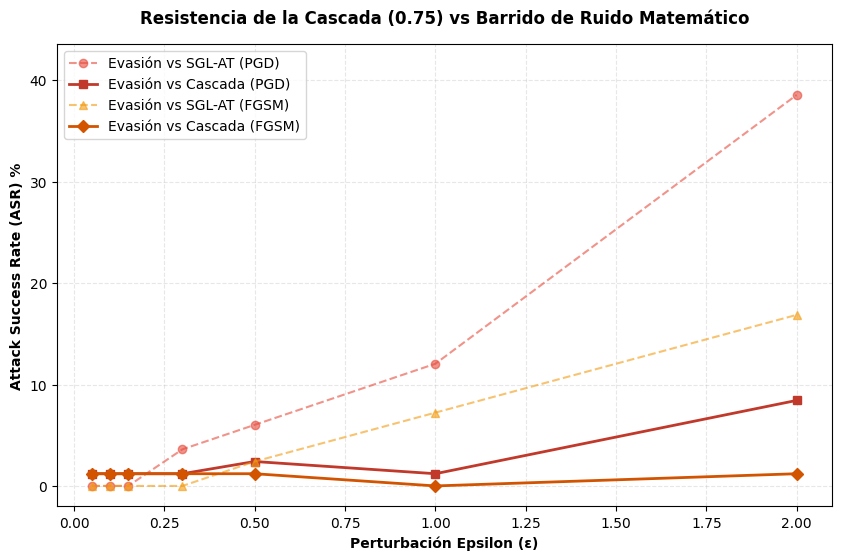

In [26]:
# ============================================================
# TANDA 1: BARRIDO EPSILON - FGSM y PGD (1500 muestras)
# Evaluado sobre la Arquitectura de Triaje en Cascada (0.75)
# ============================================================
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.attacks.fgsm import FGSMAttack
from src.attacks.pgd import PGDAttack

# --- 1. ASEGURAR DATOS ---
if 'X_ataques_sc' not in locals():
    print("[-] Generando muestra de 1500 flujos para el barrido...")
    indices = np.random.choice(len(X_test), 1500, replace=False)
    X_sub = X_test[indices]
    y_sub = y_test[indices]
else:
    X_sub = X_ataques_sc[:1500]
    y_sub = y_ataques[:1500]

epsilons = [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]
results = {'FGSM': {'asr_sglat': [], 'asr_cascada': [], 'int': []},
           'PGD': {'asr_sglat': [], 'asr_cascada': [], 'int': []}}

print("\n" + "=" * 75)
print(f"Lanzando Tanda 1 sobre {len(X_sub)} muestras (Cascada a 0.75)...")
print("=" * 75)

start_time = time.time()

for eps in epsilons:
    print(f"\n[ε={eps}] Ejecutando...")

    # Ataque FGSM
    atk_fgsm = FGSMAttack(constraints=dc, epsilon=eps, device=device)
    atk_fgsm.verbose = False
    res_fgsm = atk_fgsm.run(X_sub, y_sub, sglat_model)

    # Ataque PGD
    atk_pgd = PGDAttack(constraints=dc, epsilon=eps, alpha=eps/5.0, steps=40, random_start=True, device=device)
    atk_pgd.verbose = False
    res_pgd = atk_pgd.run(X_sub, y_sub, sglat_model)

    for name, res in [('FGSM', res_fgsm), ('PGD', res_pgd)]:
        # 1. ASR de SGL-AT puro
        asr_base = res.asr * 100
        results[name]['asr_sglat'].append(asr_base)

        # 2. Extraer X adversarial
        X_adv_data = getattr(res, 'X_adv', getattr(res, 'X_trojan', getattr(res, 'X_lsf', None)))

        # Máscara de flujos válidos (detectados por Original)
        mask_valida = (res.y_pred_orig != 0)
        total_eval = mask_valida.sum()

        if total_eval == 0 or X_adv_data is None:
            results[name]['asr_cascada'].append(0)
            results[name]['int'].append(100.0)
            print(f"   {name:<4} ASR: {asr_base:5.1f}% | Cascada: 0.0% (Inmune)")
            continue

        # 3. EVALUACIÓN EN CASCADA (Umbral 0.75)
        preds_casc, _, _ = predict_cascade_ultimate(X_adv_data, original_model, sglat_model, vae, device)

        # ASR Cascada: Los que lograron engañar a TODO el sistema
        evadidos_casc = (preds_casc[mask_valida] == 0).sum()
        asr_casc = (evadidos_casc / total_eval) * 100
        results[name]['asr_cascada'].append(asr_casc)

        # Tasa de Intercepción: ¿Cuánto mejoró la Cascada vs SGL-AT?
        y_adv_sglat = getattr(res, 'y_pred_adv', getattr(res, 'y_pred_trojan', getattr(res, 'y_pred_lsf', None)))
        evadidos_sglat = ((y_adv_sglat[mask_valida] == 0)).sum()

        if evadidos_sglat == 0:
             tasa_int = 100.0
             print(f"   {name:<4} ASR SGL-AT: {asr_base:5.1f}% | Cascada: {asr_casc:5.1f}% (Bloqueo Total)")
        else:
             # De los que evadieron SGL-AT, ¿cuántos cazó el VAE en la Cascada?
             interceptados = evadidos_sglat - evadidos_casc
             tasa_int = (interceptados / evadidos_sglat) * 100 if evadidos_sglat > 0 else 100
             print(f"   {name:<4} ASR SGL-AT: {asr_base:5.1f}% | Cascada baja el ASR a: {asr_casc:5.1f}%")

        results[name]['int'].append(tasa_int)

print(f"\n[#] Tiempo total Tanda 1: {(time.time() - start_time)/60:.1f} minutos.")

# --- Visualización ---
plt.figure(figsize=(10, 6))
plt.plot(epsilons, results['PGD']['asr_sglat'], 'o--', color='#e74c3c', alpha=0.6, label='Evasión vs SGL-AT (PGD)')
plt.plot(epsilons, results['PGD']['asr_cascada'], 's-', color='#c0392b', linewidth=2, label='Evasión vs Cascada (PGD)')
plt.plot(epsilons, results['FGSM']['asr_sglat'], '^--', color='#f39c12', alpha=0.6, label='Evasión vs SGL-AT (FGSM)')
plt.plot(epsilons, results['FGSM']['asr_cascada'], 'D-', color='#d35400', linewidth=2, label='Evasión vs Cascada (FGSM)')

plt.xlabel('Perturbación Epsilon (ε)', fontweight='bold')
plt.ylabel('Attack Success Rate (ASR) %', fontweight='bold')
plt.title('Resistencia de la Cascada (0.75) vs Barrido de Ruido Matemático', fontweight='bold', pad=15)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.ylim(-2, max(max(results['PGD']['asr_sglat']), max(results['FGSM']['asr_sglat'])) + 5)
plt.show()

## TANDA 2: **Ataques de Optimización y Espacio Latente (White-box avanzada - Medios)**
- ACE Y DLA

[✓] Capa detectada para DLA: res_blocks.2

TANDA 2: ACE & DLA — Robustez de SGL-AT + Cascada (0.75)
Muestra: 1500 flujos | Steps: 40

[ε=0.05]
    [ACE] ASR SGL-AT:   0.0% | Cascada baja el ASR a:   1.2%
    [DLA] ASR SGL-AT:   0.0% | Cascada baja el ASR a:   2.4%

[ε=0.1]
    [ACE] ASR SGL-AT:   1.2% | Cascada baja el ASR a:   2.4%
    [DLA] ASR SGL-AT:   0.0% | Cascada baja el ASR a:   2.4%

[ε=0.15]
    [ACE] ASR SGL-AT:   0.0% | Cascada baja el ASR a:   1.2%
    [DLA] ASR SGL-AT:   1.2% | Cascada baja el ASR a:   2.4%

[ε=0.3]
    [ACE] ASR SGL-AT:   2.4% | Cascada baja el ASR a:   0.0%
    [DLA] ASR SGL-AT:   1.2% | Cascada baja el ASR a:   1.2%

[ε=0.5]
    [ACE] ASR SGL-AT:   4.8% | Cascada baja el ASR a:   1.2%
    [DLA] ASR SGL-AT:   1.2% | Cascada baja el ASR a:   1.2%

[ε=1.0]
    [ACE] ASR SGL-AT:   6.0% | Cascada baja el ASR a:   2.4%
    [DLA] ASR SGL-AT:   2.4% | Cascada baja el ASR a:   1.2%

[ε=2.0]
    [ACE] ASR SGL-AT:   3.6% | Cascada baja el ASR a:   0.0%
    [DLA]

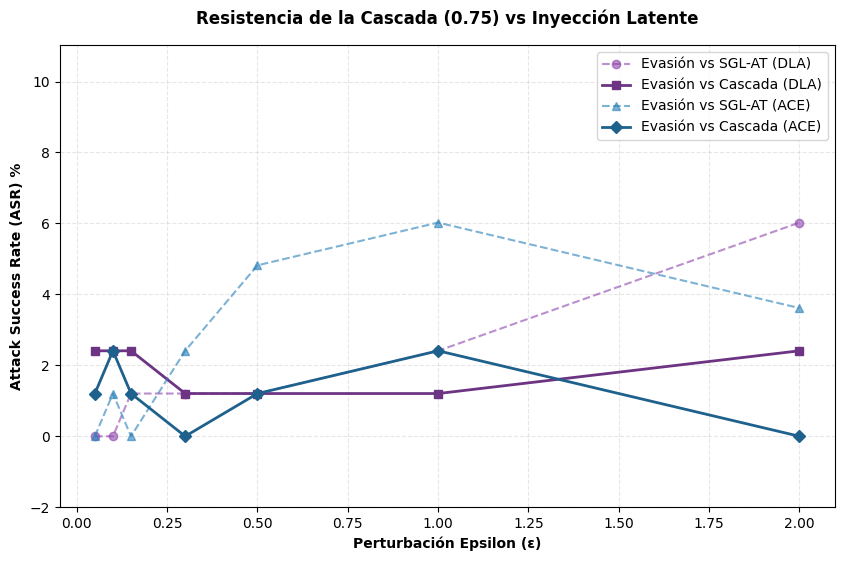

In [27]:
# ============================================================
# TANDA 2: BARRIDO EPSILON - ACE y DLA
# Evaluado sobre la Arquitectura de Triaje en Cascada (0.75)
# ============================================================
from src.attacks.ace import ACEAttack
from src.attacks.dla import DLAAttack
import time
import matplotlib.pyplot as plt

# 1. Localizar el objeto de la capa correcto
try:
    target_layer_obj = sglat_model.model.res_blocks[2]
    print(f"[✓] Capa detectada para DLA: res_blocks.2")
except Exception as e:
    target_layer_obj = sglat_model.model.res_blocks[-1]
    print(f"[!] Usando bloque residual final como fallback: {e}")

if 'X_anchors' not in locals():
    X_anchors = X_test[y_test == 0][:200]

print("\n" + "=" * 75)
print(f"TANDA 2: ACE & DLA — Robustez de SGL-AT + Cascada (0.75)")
print(f"Muestra: {len(X_sub)} flujos | Steps: 40")
print("=" * 75)

results_t2 = {'ACE': {'asr_sglat': [], 'asr_cascada': []}, 'DLA': {'asr_sglat': [], 'asr_cascada': []}}
start_time = time.time()

for eps in epsilons:
    print(f"\n[ε={eps}]")

    atk_ace = ACEAttack(constraints=dc, epsilon=eps, device=device)
    atk_ace.verbose = False
    if hasattr(atk_ace, 'steps'): atk_ace.steps = 40
    res_ace = atk_ace.run(X_sub, y_sub, sglat_model)

    atk_dla = DLAAttack(constraints=dc, target_layer=target_layer_obj, X_anchors=X_anchors, epsilon=eps, device=device)
    atk_dla.verbose = False
    if hasattr(atk_dla, 'steps'): atk_dla.steps = 40
    res_dla = atk_dla.run(X_sub, y_sub, sglat_model)

    for name, res in [('ACE', res_ace), ('DLA', res_dla)]:
        asr_base = res.asr * 100
        results_t2[name]['asr_sglat'].append(asr_base)

        X_adv_data = res.X_adv
        mask_valida = (res.y_pred_orig != 0)
        total_eval = mask_valida.sum()

        if total_eval == 0:
            results_t2[name]['asr_cascada'].append(0)
            print(f"    [{name}] ASR SGL-AT: {asr_base:5.1f}% | Cascada: 0.0% (Inmune)")
        else:
            preds_casc, _, _ = predict_cascade_ultimate(X_adv_data, original_model, sglat_model, vae, device)
            evadidos_casc = (preds_casc[mask_valida] == 0).sum()
            asr_casc = (evadidos_casc / total_eval) * 100

            results_t2[name]['asr_cascada'].append(asr_casc)
            print(f"    [{name}] ASR SGL-AT: {asr_base:5.1f}% | Cascada baja el ASR a: {asr_casc:5.1f}%")

print(f"\n[#] Tiempo Tanda 2: {(time.time() - start_time)/60:.1f} min.")

# --- Visualización ---
plt.figure(figsize=(10, 6))
plt.plot(epsilons, results_t2['DLA']['asr_sglat'], 'o--', color='#8e44ad', alpha=0.6, label='Evasión vs SGL-AT (DLA)')
plt.plot(epsilons, results_t2['DLA']['asr_cascada'], 's-', color='#6c3483', linewidth=2, label='Evasión vs Cascada (DLA)')
plt.plot(epsilons, results_t2['ACE']['asr_sglat'], '^--', color='#2980b9', alpha=0.6, label='Evasión vs SGL-AT (ACE)')
plt.plot(epsilons, results_t2['ACE']['asr_cascada'], 'D-', color='#1f618d', linewidth=2, label='Evasión vs Cascada (ACE)')

plt.xlabel('Perturbación Epsilon (ε)', fontweight='bold')
plt.ylabel('Attack Success Rate (ASR) %', fontweight='bold')
plt.title('Resistencia de la Cascada (0.75) vs Inyección Latente', fontweight='bold', pad=15)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.ylim(-2, max(max(results_t2['DLA']['asr_sglat']), max(results_t2['ACE']['asr_sglat'])) + 5)
plt.show()

TANDA 3: **Ataques Sigilosos (Black-Box sofisticados - Lentos)**
- S3M Y LSF

In [28]:
# ============================================================
# TANDA 3: BARRIDO SEMÁNTICO - S3M y LSF (CASCADA 0.75)
# ============================================================
from src.attacks.s3m_attack import S3MAttack
from src.attacks.lsf import LSFAttack
import time
import numpy as np

# --- 1. BLOQUE DE SEGURIDAD PARA VARIABLES ---
if 'CLASS_MAP' not in locals():
    CLASS_MAP = {
        0: 'Benign', 1: 'DDoS', 2: 'PortScan', 3: 'Bot',
        4: 'Infiltration', 5: 'Web Attack', 6: 'Brute Force', 7: 'DoS'
    }

if 'X_benign_sc' not in locals():
    print("[-] Recuperando tráfico benigno del test set...")
    X_benign_sc = X_test[y_test == 0]

print("\n" + "=" * 75)
print(f"TANDA 3: S3M & LSF — Ataques de Camuflaje Semántico vs Cascada (0.75)")
print(f"Muestra: {len(X_sub)} flujos | n_twins=50")
print("=" * 75)

# --- 2. CONFIGURACIÓN ---
s3m_sglat = S3MAttack(
    constraints     = dc,
    X_benign_scaled = X_benign_sc,
    mode            = 'adaptive',
    twin_selection  = 'semantic',
    preserve_payload= True,
    n_twins         = 50,
    verbose         = False,
)

lsf_sglat = LSFAttack(
    constraints     = dc,
    X_benign_scaled = X_benign_sc,
    n_twins         = 50,
    verbose         = False,
)

start_time = time.time()

# --- 3. EJECUCIÓN ---
print(f"\n[1/2] Lanzando S3M (Sustitución Semántica)...")
res_s3m = s3m_sglat.run(X_sub, y_sub, sglat_model, CLASS_MAP)

print(f"[2/2] Lanzando LSF v3 (Falsificación Latente)...")
res_lsf = lsf_sglat.run(X_sub, y_sub, sglat_model, CLASS_MAP)

# --- 4. EVALUACIÓN DE LA CASCADA ---
results_t3 = {'S3M': res_s3m, 'LSF': res_lsf}

print("\n" + "=" * 70)
print("EVALUACIÓN FINAL: ASR SGL-AT vs ASR CASCADA TOTAL")
print("=" * 70)

for name, res in results_t3.items():
    # Extraer variables del objeto de resultados
    X_adv_data = getattr(res, 'X_lsf', getattr(res, 'X_adv', getattr(res, 'X_trojan', None)))
    y_pred_base = getattr(res, 'y_pred_orig', None)
    y_adv_sglat = getattr(res, 'y_pred_lsf', getattr(res, 'y_pred_adv', getattr(res, 'y_pred_trojan', None)))

    if X_adv_data is None or y_pred_base is None or y_adv_sglat is None:
        print(f"  [!] Error leyendo datos del ataque {name}.")
        continue

    # Solo evaluamos flujos que la Original detectaba antes del ataque
    mask_valida = (y_pred_base != 0)
    total_eval = mask_valida.sum()

    if total_eval == 0:
        print(f"  [{name}] ASR SGL-AT:  0.0% | Cascada:  0.0% (Inmune de base)")
    else:
        # 1. ASR contra SGL-AT puro
        evadidos_sglat = (y_adv_sglat[mask_valida] == 0).sum()
        asr_sglat = (evadidos_sglat / total_eval) * 100

        # 2. ASR contra la Cascada Total
        preds_casc, _, _ = predict_cascade_ultimate(X_adv_data, original_model, sglat_model, vae, device)
        evadidos_casc = (preds_casc[mask_valida] == 0).sum()
        asr_casc = (evadidos_casc / total_eval) * 100

        # Formateo visual
        if asr_casc == 0:
            status = "[/\\] IMPENETRABLE"
        elif asr_casc < asr_sglat:
            status = "[X] CASCADA MEJORA LA DEFENSA"
        elif asr_casc == asr_sglat:
            status = "[=] EMPATE TÉCNICO"
        else:
            status = "[!] CASCADA EXCEDE PERMISIVIDAD"

        print(f"\n  -> Ataque {name}:")
        print(f"      ASR SGL-AT puro  : {asr_sglat:>5.1f}%")
        print(f"      ASR Cascada Total: {asr_casc:>5.1f}%  -> {status}")

print(f"\nTiempo Tanda 3: {(time.time() - start_time)/60:.1f} min.")
print("=" * 70)

<>:87: SyntaxWarning: invalid escape sequence '\]'
<>:87: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_671/2219965026.py:87: SyntaxWarning: invalid escape sequence '\]'
  status = "[/\] IMPENETRABLE"



TANDA 3: S3M & LSF — Ataques de Camuflaje Semántico vs Cascada (0.75)
Muestra: 1500 flujos | n_twins=50

[1/2] Lanzando S3M (Sustitución Semántica)...
[2/2] Lanzando LSF v3 (Falsificación Latente)...

EVALUACIÓN FINAL: ASR SGL-AT vs ASR CASCADA TOTAL

  -> Ataque S3M:
      ASR SGL-AT puro  : 100.0%
      ASR Cascada Total:  67.5%  -> [X] CASCADA MEJORA LA DEFENSA

  -> Ataque LSF:
      ASR SGL-AT puro  :  75.9%
      ASR Cascada Total:  31.3%  -> [X] CASCADA MEJORA LA DEFENSA

Tiempo Tanda 3: 1.5 min.


DIAGNÓSTICO DE RESULTADOS S3M Y LSF

In [29]:
# ============================================================
# DIAGNÓSTICO PROFUNDO: S3M & LSF (Versión Multi-Formato)
# ============================================================
import numpy as np

def analizar_detalles_ataque(result, name, class_map_obj):
    # 1. Extracción de Atributos
    X_orig = result.X_original
    y_true = result.y_true

    # Datos adversariales
    X_adv = getattr(result, 'X_lsf', getattr(result, 'X_adv', getattr(result, 'X_trojan', None)))

    # Predicciones post-ataque
    y_adv = getattr(result, 'y_pred_lsf', getattr(result, 'y_pred_adv', getattr(result, 'y_pred_trojan', None)))

    if X_adv is None or y_adv is None:
        print(f"\n[!] Error: No se encontraron datos/predicciones en {name}")
        return

    print(f"\n" + "="*65)
    print(f" ANÁLISIS FORENSE: {name}")
    print("="*65)

    # --- MÉTRICAS DE PERTURBACIÓN ---
    delta = X_adv - X_orig
    l0 = (np.abs(delta) > 1e-6).sum(axis=1)
    l2 = np.linalg.norm(delta, axis=1)
    linf = np.abs(delta).max(axis=1)

    print(f"\n  [*] Huella de Perturbación:")
    print(f"    - Features modificadas (L0) : {l0.mean():.1f} / {X_orig.shape[1]}")
    print(f"    - Distancia Euclidiana (L2) : {l2.mean():.4f}")
    print(f"    - Perturbación Máxima (Linf): {linf.mean():.4f}")

    # --- DESGLOSE POR CLASE ---
    print(f"\n  [X] Evasión por Clase (ASR Individual):")
    mask_det = result.y_pred_orig != 0

    for cls in np.unique(y_true):
        if cls == 0: continue
        m_cls = (y_true == cls) & mask_det
        if m_cls.sum() == 0: continue

        # Cálculo de ASR para esta clase
        asr_cls = (y_adv[m_cls] == 0).mean() * 100

        # Lógica compatible para obtener el nombre de la clase (Lista o Diccionario)
        try:
            if isinstance(class_map_obj, list):
                c_name = class_map_obj[int(cls)]
            else:
                c_name = class_map_obj.get(int(cls), f"Clase {cls}")
        except:
            c_name = f"Clase {cls}"

        print(f"    {c_name:<18} : {asr_cls:>6.1f}% ({m_cls.sum():>3} flujos)")

    # --- ANÁLISIS DE INTERCEPCIÓN VAE ---
    mask_evadidos = mask_det & (y_adv == 0)
    if mask_evadidos.sum() > 0:
        p_final, stats, _ = predict_hybrid_pipeline(X_adv[mask_evadidos], sglat_model, vae, device)
        interceptados = (p_final != 0).sum()
        tasa = (interceptados / mask_evadidos.sum()) * 100

        print(f"\n  [#] Rescate del Guardián VAE:")
        print(f"    - Flujos que burlaron SGL-AT : {mask_evadidos.sum()}")
        print(f"    - Interceptados por el VAE   : {interceptados} ({tasa:.1f}%)")
        print(f"    - Tráfico enviado al VAE     : {stats['routed_to_vae'] / mask_evadidos.sum() * 100:.1f}%")

# Ejecutar diagnósticos
analizar_detalles_ataque(res_s3m, "S3M (Camuflaje Semántico)", CLASS_MAP)
analizar_detalles_ataque(res_lsf, "LSF v3 (Falsificación Latente)", CLASS_MAP)

# Ablación LSF
if hasattr(res_lsf, 'asr_ppe_tcc'):
    print("\n" + "="*65)
    print(" ABLACIÓN POR CAPAS (LSF)")
    print("="*65)
    print(f"  - Capa 1+2 (PPE + TCC)     : {res_lsf.asr_ppe_tcc*100:.1f}% ASR")
    print(f"  - Capa 3 (LSF Completo)    : {res_lsf.asr_lsf*100:.1f}% ASR")


 ANÁLISIS FORENSE: S3M (Camuflaje Semántico)

  [*] Huella de Perturbación:
    - Features modificadas (L0) : 36.5 / 66
    - Distancia Euclidiana (L2) : 4.7267
    - Perturbación Máxima (Linf): 3.1134

  [X] Evasión por Clase (ASR Individual):
    DoS                :  100.0% (  9 flujos)
    DDoS               :  100.0% ( 30 flujos)
    Web/Injection      :  100.0% ( 10 flujos)
    Brute Force        :  100.0% ( 11 flujos)
    Recon              :  100.0% (  5 flujos)
    Malware            :  100.0% (  6 flujos)
    Exploits           :  100.0% (  5 flujos)

  [#] Rescate del Guardián VAE:
    - Flujos que burlaron SGL-AT : 83
    - Interceptados por el VAE   : 25 (30.1%)
    - Tráfico enviado al VAE     : 47.0%

 ANÁLISIS FORENSE: LSF v3 (Falsificación Latente)

  [*] Huella de Perturbación:
    - Features modificadas (L0) : 54.7 / 66
    - Distancia Euclidiana (L2) : 30.4330
    - Perturbación Máxima (Linf): 9.6264

  [X] Evasión por Clase (ASR Individual):
    DoS               

# Intercepción VAE - Ataques que SGL-AT no detuvo (con Gating)

In [30]:
# ── 7. Análisis de Intercepción VAE (Pipeline Real - Arsenal Completo) ──
print("\n" + "=" * 80)
print("INTERCEPCIÓN VAE — Radiografía de los ataques que SGL-AT no detuvo")
print("=" * 80)

# Mapeo de variables basado en lo que hemos ejecutado hoy
ataques_residuales = {}

# Intentamos recolectar todo lo que hay en memoria de las 3 Tandas
# Tanda 3 (Semánticos)
if 'res_s3m' in locals(): ataques_residuales['S3M (Camuflaje Semántico)'] = res_s3m
if 'res_lsf' in locals(): ataques_residuales['LSF (Inyección Latente)'] = res_lsf

# Tanda 2 (Avanzados)
if 'res_ace' in locals(): ataques_residuales['ACE (Ataque Optimizado)'] = res_ace
if 'res_dla' in locals(): ataques_residuales['DLA (Secuestro Latente)'] = res_dla

# Tanda 1 (Gradiente - Tomamos el último epsilon ejecutado)
if 'res_pgd' in locals(): ataques_residuales['PGD (Ataque Gradiente)'] = res_pgd
if 'res_fgsm' in locals(): ataques_residuales['FGSM (Ataque Simple)'] = res_fgsm

if not ataques_residuales:
    print(" [!] No se han encontrado resultados de ataques. Ejecuta las tandas anteriores primero.")
else:
    for nombre, result_atk in ataques_residuales.items():
        # Extracción robusta de datos adversariales
        X_adv = getattr(result_atk, 'X_lsf', getattr(result_atk, 'X_adv', getattr(result_atk, 'X_trojan', None)))
        y_pred_adv = getattr(result_atk, 'y_pred_lsf', getattr(result_atk, 'y_pred_adv', getattr(result_atk, 'y_pred_trojan', None)))

        if X_adv is None or y_pred_adv is None:
            continue

        # 1. Filtramos: ¿Cuáles lograron EVADIR a SGL-AT?
        # (Filtramos también que el original sí los detectara para ser rigurosos)
        orig_detected_mask = (result_atk.y_pred_orig != 0)
        evadieron_sglat_mask = orig_detected_mask & (y_pred_adv == 0)
        total_evadidos = evadieron_sglat_mask.sum()

        if total_evadidos == 0:
            print(f"\n  {nombre:<30} : [✓] SGL-AT lo paró todo.")
            continue

        # 2. Pasamos los supervivientes por el Pipeline Híbrido
        X_evadidos = X_adv[evadieron_sglat_mask]
        preds_pipeline, stats, _ = predict_hybrid_pipeline(
            X_evadidos, sglat_model, vae, device, conf_threshold=0.85
        )

        # 3. Cálculo de Intercepción
        interceptados = (preds_pipeline != 0).sum()
        tasa = (interceptados / total_evadidos) * 100

        print(f"\n  {nombre}:")
        print(f"    - Burlaron SGL-AT            : {total_evadidos:,} flujos")
        print(f"    - Identificados como 'Dudosos' : {stats['routed_to_vae']:,}")
        print(f"    - VAE los INTERCEPTÓ         : {interceptados:,} ({tasa:.1f}%)")

print("\n" + "=" * 80)


INTERCEPCIÓN VAE — Radiografía de los ataques que SGL-AT no detuvo

  S3M (Camuflaje Semántico):
    - Burlaron SGL-AT            : 83 flujos
    - Identificados como 'Dudosos' : 39
    - VAE los INTERCEPTÓ         : 25 (30.1%)

  LSF (Inyección Latente):
    - Burlaron SGL-AT            : 63 flujos
    - Identificados como 'Dudosos' : 40
    - VAE los INTERCEPTÓ         : 40 (63.5%)

  ACE (Ataque Optimizado):
    - Burlaron SGL-AT            : 3 flujos
    - Identificados como 'Dudosos' : 3
    - VAE los INTERCEPTÓ         : 3 (100.0%)

  DLA (Secuestro Latente):
    - Burlaron SGL-AT            : 5 flujos
    - Identificados como 'Dudosos' : 5
    - VAE los INTERCEPTÓ         : 4 (80.0%)

  PGD (Ataque Gradiente):
    - Burlaron SGL-AT            : 32 flujos
    - Identificados como 'Dudosos' : 27
    - VAE los INTERCEPTÓ         : 27 (84.4%)

  FGSM (Ataque Simple):
    - Burlaron SGL-AT            : 14 flujos
    - Identificados como 'Dudosos' : 13
    - VAE los INTERCEPTÓ       

# TRAZABILIDAD DE LOS ATAQUES QUE HAN TRASPASADO TODAS LAS DEFENSAS

In [31]:
import pandas as pd

# ── 8. Reporte de Trazabilidad Total (Análisis por Clase de Ataque) ──
print("\n" + "=" * 85)
print("REPORTE DE TRAZABILIDAD: Desglose de Intercepción por Clase de Malicious Traffic")
print("=" * 85)

# Lista para recolectar filas del reporte final
report_data = []

for nombre_ataque, result_atk in ataques_residuales.items():
    # 1. Extracción de datos
    X_adv = getattr(result_atk, 'X_lsf', getattr(result_atk, 'X_adv', getattr(result_atk, 'X_trojan', None)))
    y_true = result_atk.y_true
    y_pred_adv = getattr(result_atk, 'y_pred_lsf', getattr(result_atk, 'y_pred_adv', getattr(result_atk, 'y_pred_trojan', None)))

    # 2. Identificar quiénes burlaron SGL-AT
    orig_detected_mask = (result_atk.y_pred_orig != 0)
    evadieron_sglat_mask = orig_detected_mask & (y_pred_adv == 0)

    if evadieron_sglat_mask.sum() == 0:
        continue

    # 3. Analizar por clase dentro de este ataque específico
    clases_evadidas = np.unique(y_true[evadieron_sglat_mask])

    for cls_id in clases_evadidas:
        # Máscara específica para esta clase que evadió SGL-AT
        mask_cls = evadieron_sglat_mask & (y_true == cls_id)
        n_evadidos = mask_cls.sum()

        if n_evadidos == 0: continue

        # 4. Pasar esa clase específica por el Pipeline
        X_cls_evadidos = X_adv[mask_cls]
        preds_pipeline, stats, _ = predict_hybrid_pipeline(
            X_cls_evadidos, sglat_model, vae, device, conf_threshold=0.85
        )

        n_interceptados = (preds_pipeline != 0).sum()
        tasa_int = (n_interceptados / n_evadidos) * 100

        # Guardamos en la lista
        try:
            nombre_clase = CLASS_MAP[int(cls_id)] if isinstance(CLASS_MAP, dict) else CLASS_MAP[int(cls_id)]
        except:
            nombre_clase = f"Clase {cls_id}"

        report_data.append({
            'Ataque': nombre_ataque,
            'Clase de Tráfico': nombre_clase,
            'Evadieron SGL-AT': n_evadidos,
            'Interceptados VAE': n_interceptados,
            'Tasa Éxito VAE (%)': round(tasa_int, 1),
            'Dudosos (Gating %)': round((stats['routed_to_vae']/n_evadidos)*100, 1)
        })

# Crear DataFrame y mostrar
df_trace = pd.DataFrame(report_data)
display(df_trace.sort_values(by='Tasa Éxito VAE (%)', ascending=False))

# --- Exportación para tu memoria ---
df_trace.to_csv("trazabilidad_ataques_fase3.csv", index=False)
print("\n[✓] Archivo 'trazabilidad_ataques_fase3.csv' guardado para MEMORIA TFG.")


REPORTE DE TRAZABILIDAD: Desglose de Intercepción por Clase de Malicious Traffic


,Ataque,Clase de Tráfico,Evadieron SGL-AT,Interceptados VAE,Tasa Éxito VAE (%),Dudosos (Gating %)
17,ACE (Ataque Optimizado),DoS,1,1,100.0,100.0
16,ACE (Ataque Optimizado),Benign,1,1,100.0,100.0
15,LSF (Inyección Latente),Exploits,5,5,100.0,100.0
27,PGD (Ataque Gradiente),Malware,3,3,100.0,100.0
28,PGD (Ataque Gradiente),Exploits,5,5,100.0,100.0
29,FGSM (Ataque Simple),Benign,3,3,100.0,100.0
18,ACE (Ataque Optimizado),Malware,1,1,100.0,100.0
33,FGSM (Ataque Simple),Malware,1,1,100.0,100.0
25,PGD (Ataque Gradiente),Web/Injection,5,5,100.0,100.0
32,FGSM (Ataque Simple),Brute Force,3,3,100.0,100.0



[✓] Archivo 'trazabilidad_ataques_fase3.csv' guardado para MEMORIA TFG.


# Tabla Final - Sistema defensivo completo

In [32]:
import pickle
import os
import pandas as pd

print("\n" + "=" * 75)
print("GUARDADO MAESTRO DE ARTEFACTOS - FASE 3")
print("=" * 75)

# 1. Preparar el diccionario de guardado
# Incluimos los resultados del pipeline y todos los ataques ejecutados
checkpoint_fase3 = {
    'pipeline_metrics': results_pipeline,
    'ataques': {
        's3m': res_s3m if 'res_s3m' in locals() else None,
        'lsf': res_lsf if 'res_lsf' in locals() else None,
        'ace': res_ace if 'res_ace' in locals() else None,
        'dla': res_dla if 'res_dla' in locals() else None,
        'pgd': res_pgd if 'res_pgd' in locals() else None,
    },
    'trazabilidad_df': df_trace if 'df_trace' in locals() else None
}

# 2. Imprimir la Tabla Maestra (Tu código original mejorado)
print("\n[X] RESUMEN GENERAL PARA LA MEMORIA:")
col_w = 20
header = (f"{'Configuración':<{col_w}} | {'F1-macro':>9} | "
          f"{'Att.Recall':>11} | {'FPR':>7} | {'FNR':>7} | {'VAE%':>6}")
print(header)
print("-" * len(header))

for name, r in results_pipeline.items():
    print(f"{name:<{col_w}} | "
          f"{r['f1_macro']:>9.4f} | "
          f"{r['attack_recall']:>11.4f} | "
          f"{r['fpr']:>7.4f} | "
          f"{r['fnr']:>7.4f} | "
          f"{r['stats']['vae_pct']:>5.1f}%")

# 3. Guardado físico de archivos
try:
    # Guardamos el objeto completo (binario)
    pkl_path = os.path.join(FASE3_DIR, "checkpoint_completo_fase3.pkl")
    with open(pkl_path, 'wb') as f:
        pickle.dump(checkpoint_fase3, f)

    # Guardamos la tabla de trazabilidad en CSV para Excel/Word
    if 'df_trace' in locals():
        csv_path = os.path.join(FASE3_DIR, "trazabilidad_detallada.csv")
        df_trace.to_csv(csv_path, index=False)
        print(f"\n[✓] CSV de trazabilidad guardado: {csv_path}")

    # Guardamos un resumen en texto para copiar/pegar rápido
    txt_path = os.path.join(FASE3_DIR, "resumen_ejecutivo.txt")
    with open(txt_path, 'w') as f:
        f.write(header + "\n" + "-"*len(header) + "\n")
        for name, r in results_pipeline.items():
            line = f"{name:<{col_w}} | {r['f1_macro']:>9.4f} | {r['attack_recall']:>11.4f} | {r['fpr']:>7.4f} | {r['fnr']:>7.4f} | {r['stats']['vae_pct']:>5.1f}%\n"
            f.write(line)

    print(f"[✓] Checkpoint binario guardado en: {pkl_path}")
    print(f"[✓] ¡Todo listo! Ya puedes cerrar Colab sin miedo a perder los datos.")

except NameError:
    print("\n[!] Error: FASE3_DIR no está definida. Define la ruta de tu carpeta de Drive.")
except Exception as e:
    print(f"\n[!] Error durante el guardado: {e}")

print("=" * 75)


GUARDADO MAESTRO DE ARTEFACTOS - FASE 3

[X] RESUMEN GENERAL PARA LA MEMORIA:
Configuración        |  F1-macro |  Att.Recall |     FPR |     FNR |   VAE%
---------------------------------------------------------------------------
Original             |    0.9599 |      0.9850 |  0.0077 |  0.0150 |   0.0%
Original+VAE         |    0.9712 |      0.9609 |  0.0038 |  0.0391 |   2.1%
SGL-AT               |    0.9580 |      0.9793 |  0.0078 |  0.0207 |   0.0%
SGL-AT+VAE           |    0.9291 |      0.8477 |  0.0059 |  0.1523 |   9.2%
Cascada Total        |    0.9460 |      0.9863 |  0.0111 |  0.0137 |   3.2%

[✓] CSV de trazabilidad guardado: outputs/models/fase3_exp/trazabilidad_detallada.csv
[✓] Checkpoint binario guardado en: outputs/models/fase3_exp/checkpoint_completo_fase3.pkl
[✓] ¡Todo listo! Ya puedes cerrar Colab sin miedo a perder los datos.


# **SIMULACIÓN DE ESCENARIO ZERO-DAYS MEDIANTE ATAQUES WORMS**


EVALUACIÓN DE ZERO-DAY (WORMS) - INFERENCIA OOD
[✓] Cargadas 158 muestras de Gusanos (Zero-Day).

---------------------------------------------------------------------------
Configuración      |   Detectados |  Recall ZD | Dudosos (VAE)
---------------------------------------------------------------------------
 Original          |          135 |      85.4% |      0.0%
 Original+VAE      |          148 |      93.7% |     58.2%
 SGL-AT            |          149 |      94.3% |      0.0%
 SGL-AT+VAE        |          155 |      98.1% |     98.1%
---------------------------------------------------------------------------

[*] IMPACTO DEL GUARDÍAN VAE EN AMENAZAS DESCONOCIDAS:
  - Mejora sobre ResNet Original : +8.2 pp
  - Mejora sobre ResNet SGL-AT   : +3.8 pp


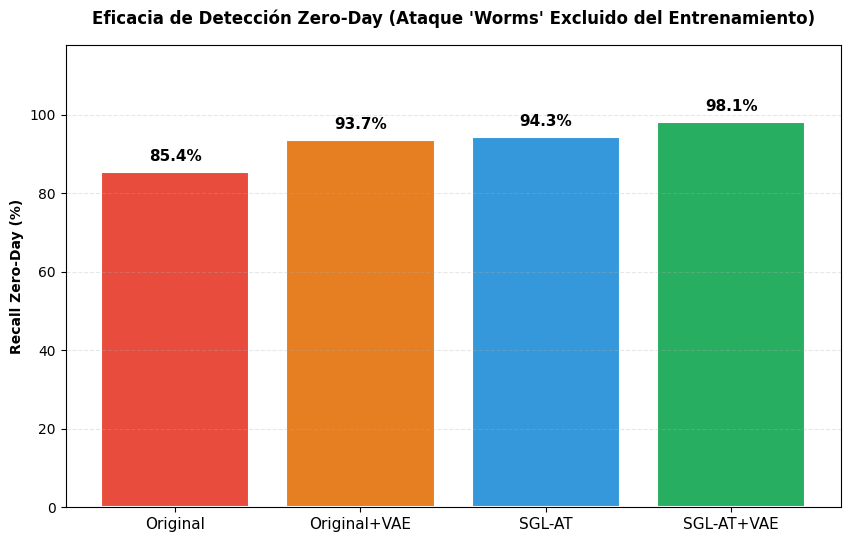


[✓] Gráfica Zero-Day guardada en: outputs/models/fase3/etapa2/zero_day_comparativa.png


In [34]:
# ============================================================
# CELDA 3: EVALUACIÓN ZERO-DAY (Versión Todo-en-Uno)
# ============================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.config import Config

# 1. Definir la función del Pipeline Híbrido (por si no estaba en memoria)
def predict_hybrid_pipeline(X_np, resnet_model, vae_model, device, conf_threshold=0.85):
    resnet_model.eval()
    X_t = torch.FloatTensor(X_np).to(device)

    with torch.no_grad():
        logits, _ = resnet_model.model(X_t)
        probs_raw = torch.softmax(logits, dim=1).cpu().numpy()

    conf = probs_raw.max(axis=1)
    preds_resnet = probs_raw.argmax(axis=1)

    # Gating: Solo enviamos al VAE si la ResNet DUDA.
    needs_vae = (conf < conf_threshold)
    preds_final = preds_resnet.copy()

    n_routed = needs_vae.sum()
    n_override = 0

    if n_routed > 0:
        X_susp = X_np[needs_vae]
        vae_scores = vae_model.anomaly_score(X_susp)
        thr = getattr(vae_model.detector, 'threshold_optimal', vae_model.detector.threshold)
        is_anomaly = (vae_scores > thr).astype(int)

        idxs = np.where(needs_vae)[0]
        for local_i, global_i in enumerate(idxs):
            if is_anomaly[local_i] == 1:
                preds_final[global_i] = 1 # Override a anomalía
                n_override += 1
            else:
                preds_final[global_i] = 0 # Confirmar benigno

    stats = {
        'total': len(X_np),
        'routed_to_vae': int(n_routed),
        'vae_pct': (n_routed / len(X_np)) * 100,
        'overridden': int(n_override),
        'direct_classify': int(len(X_np) - n_routed),
    }
    return preds_final, stats, probs_raw

print("\n" + "=" * 75)
print("EVALUACIÓN DE ZERO-DAY (WORMS) - INFERENCIA OOD")
print("=" * 75)

# 2. Cargar los datos del Zero-Day
path_worms = os.path.join(Config.DATA_PROCESSED_PATH, "..", "ataques_zero_days", "X_worms_sc.npy")

if not os.path.exists(path_worms):
    print(f"[!] ERROR: No se encuentra {path_worms}.")
else:
    X_worms = np.load(path_worms)
    n_samples = len(X_worms)
    print(f"[✓] Cargadas {n_samples:,} muestras de Gusanos (Zero-Day).")

    # 3. Configuración de evaluación
    configs_zd = {
        'Original':       original_model,
        'Original+VAE':   original_model,
        'SGL-AT':         sglat_model,
        'SGL-AT+VAE':     sglat_model,
    }
    use_vae_zd = {
        'Original':       False,
        'Original+VAE':   True,
        'SGL-AT':         False,
        'SGL-AT+VAE':     True,
    }

    resultados_zd = {}

    print("\n" + "-" * 75)
    print(f"{'Configuración':<18} | {'Detectados':>12} | {'Recall ZD':>10} | {'Dudosos (VAE)'}")
    print("-" * 75)

    # 4. Bucle de Inferencia
    for name, resnet in configs_zd.items():
        if use_vae_zd[name]:
            preds, stats, _ = predict_hybrid_pipeline(X_worms, resnet, vae, device, conf_threshold=0.85)
            enrutados_pct = stats['vae_pct']
        else:
            resnet.eval()
            X_t = torch.FloatTensor(X_worms).to(device)
            with torch.no_grad():
                logits, _ = resnet.model(X_t)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            enrutados_pct = 0.0

        # Cualquier predicción distinta de 0 (Benigno) es un éxito detectando la anomalía
        detectados = (preds != 0).sum()
        recall_zd = (detectados / n_samples) * 100

        resultados_zd[name] = {'recall': recall_zd, 'detectados': detectados, 'enrutados_pct': enrutados_pct}
        print(f" {name:<17} | {detectados:>12} | {recall_zd:>9.1f}% | {enrutados_pct:>8.1f}%")

    print("-" * 75)

    # 5. Análisis Automatizado
    ganancia_orig = resultados_zd['Original+VAE']['recall'] - resultados_zd['Original']['recall']
    ganancia_sglat = resultados_zd['SGL-AT+VAE']['recall'] - resultados_zd['SGL-AT']['recall']

    print(f"\n[*] IMPACTO DEL GUARDÍAN VAE EN AMENAZAS DESCONOCIDAS:")
    print(f"  - Mejora sobre ResNet Original : {ganancia_orig:+.1f} pp")
    print(f"  - Mejora sobre ResNet SGL-AT   : {ganancia_sglat:+.1f} pp")

    # 6. Visualización
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = {'Original': '#e74c3c', 'Original+VAE': '#e67e22', 'SGL-AT': '#3498db', 'SGL-AT+VAE': '#27ae60'}
    names = list(resultados_zd.keys())
    recalls = [resultados_zd[n]['recall'] for n in names]

    bars = ax.bar(names, recalls, color=[colors[n] for n in names], edgecolor='white', linewidth=1.5)

    ax.set_ylim(0, max(100, max(recalls) * 1.2))
    ax.set_title("Eficacia de Detección Zero-Day (Ataque 'Worms' Excluido del Entrenamiento)", fontweight='bold', pad=15, fontsize=12)
    ax.set_ylabel("Recall Zero-Day (%)", fontweight='bold')
    ax.tick_params(axis='x', rotation=0, labelsize=11)

    for bar, val in zip(bars, recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.grid(axis='y', alpha=0.3, linestyle='--')

    FASE3_DIR = os.path.join(Config.MODELS_PATH, "fase3", "etapa2")
    os.makedirs(FASE3_DIR, exist_ok=True)
    grafica_path = os.path.join(FASE3_DIR, "zero_day_comparativa.png")
    plt.savefig(grafica_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n[✓] Gráfica Zero-Day guardada en: {grafica_path}")